# Weighted Turbine Power

This notebook demonstrates the **weighted turbine power** feature in *OptiWindNet*. In real wind farms, turbines may have different rated power outputs — for example, a mix of 3 MW and 6 MW turbines on the same site. When cables are sized by the amount of power they carry, routing that ignores these differences can lead to under- or over-sized cables.

The `turbine_power` parameter in `WindFarmNetwork` lets you specify a relative power weight per turbine. The MILP optimizer will then route and size cables based on the actual power each turbine contributes, rather than treating all turbines as equal.

In this notebook we will:

* Set up a small wind farm with mixed power ratings
* Compare uniform vs. non-uniform power optimization
* Inspect how cable loads change with weighted power

In [2]:
import numpy as np
from optiwindnet.api import WindFarmNetwork, EWRouter, MILPRouter

## Setup: Wind Farm Geometry

We define a small wind farm with 8 turbines and 1 substation. The first 4 turbines have a nominal power rating (weight `1.0`) and the last 4 have a higher rating (weight `2.0`), representing a mix of e.g. 3 MW and 6 MW turbines.

In [3]:
turbinesC = np.array([
    [0, 0], [1, 0], [2, 0], [3, 0],  # 4 standard turbines (power = 1.0)
    [0, 2], [1, 2], [2, 2], [3, 2],  # 4 high-power turbines (power = 2.0)
])
substationsC = np.array([[1.5, -2]])

# power weights: last 4 turbines produce twice the nominal power
turbine_power = [1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0]

## Uniform Power (baseline)

First we optimize without specifying `turbine_power`, so all turbines 
are treated as equal. Cable capacity is set to 4 (4 turbines per feeder). 


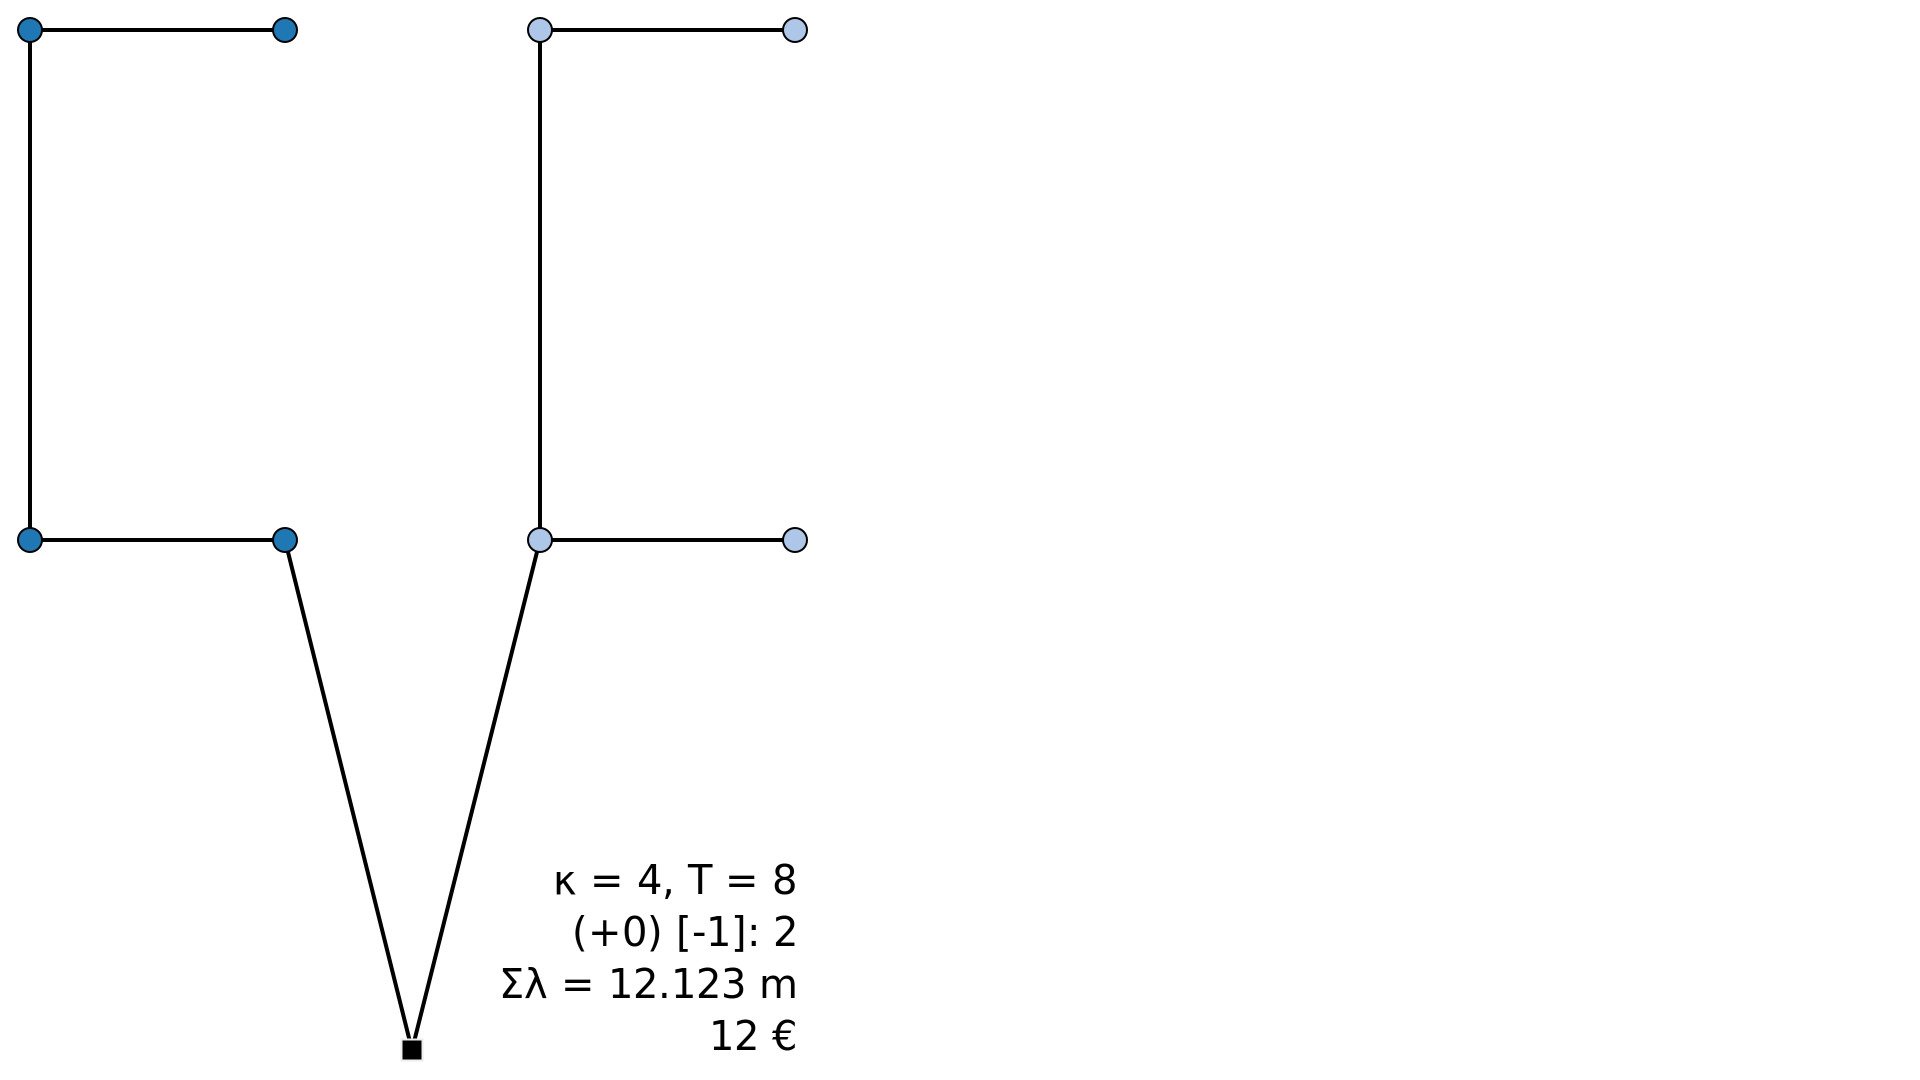

In [4]:
wfn_uniform = WindFarmNetwork(
    cables=[(4, 1.0)],
    turbinesC=turbinesC,
    substationsC=substationsC,
    router=MILPRouter('ortools', time_limit=60, mip_gap=0.01),
)
wfn_uniform.optimize()
wfn_uniform.plot()

Cable loads in the uniform case (each turbine contributes 1 unit):

In [5]:
for u, v, data in sorted(wfn_uniform.G.edges(data=True)):
    if 'load' in data:
        print(f'{u:>3} -> {v:>3}  load={data["load"]:.1f}')

 -1 ->   1  load=4.0
 -1 ->   2  load=4.0
  0 ->   1  load=3.0
  0 ->   4  load=2.0
  2 ->   6  load=2.0
  3 ->   2  load=1.0
  4 ->   5  load=1.0
  6 ->   7  load=1.0


## Non-Uniform Power

Now we pass `turbine_power` to reflect the mixed fleet. 
The cable capacity is kept at 4 nominal power units per feeder, 
so a feeder with two high-power turbines (each = 2 units) is already at capacity. 
We use `node_tag='power'` to display each turbine's power weight on the plot.

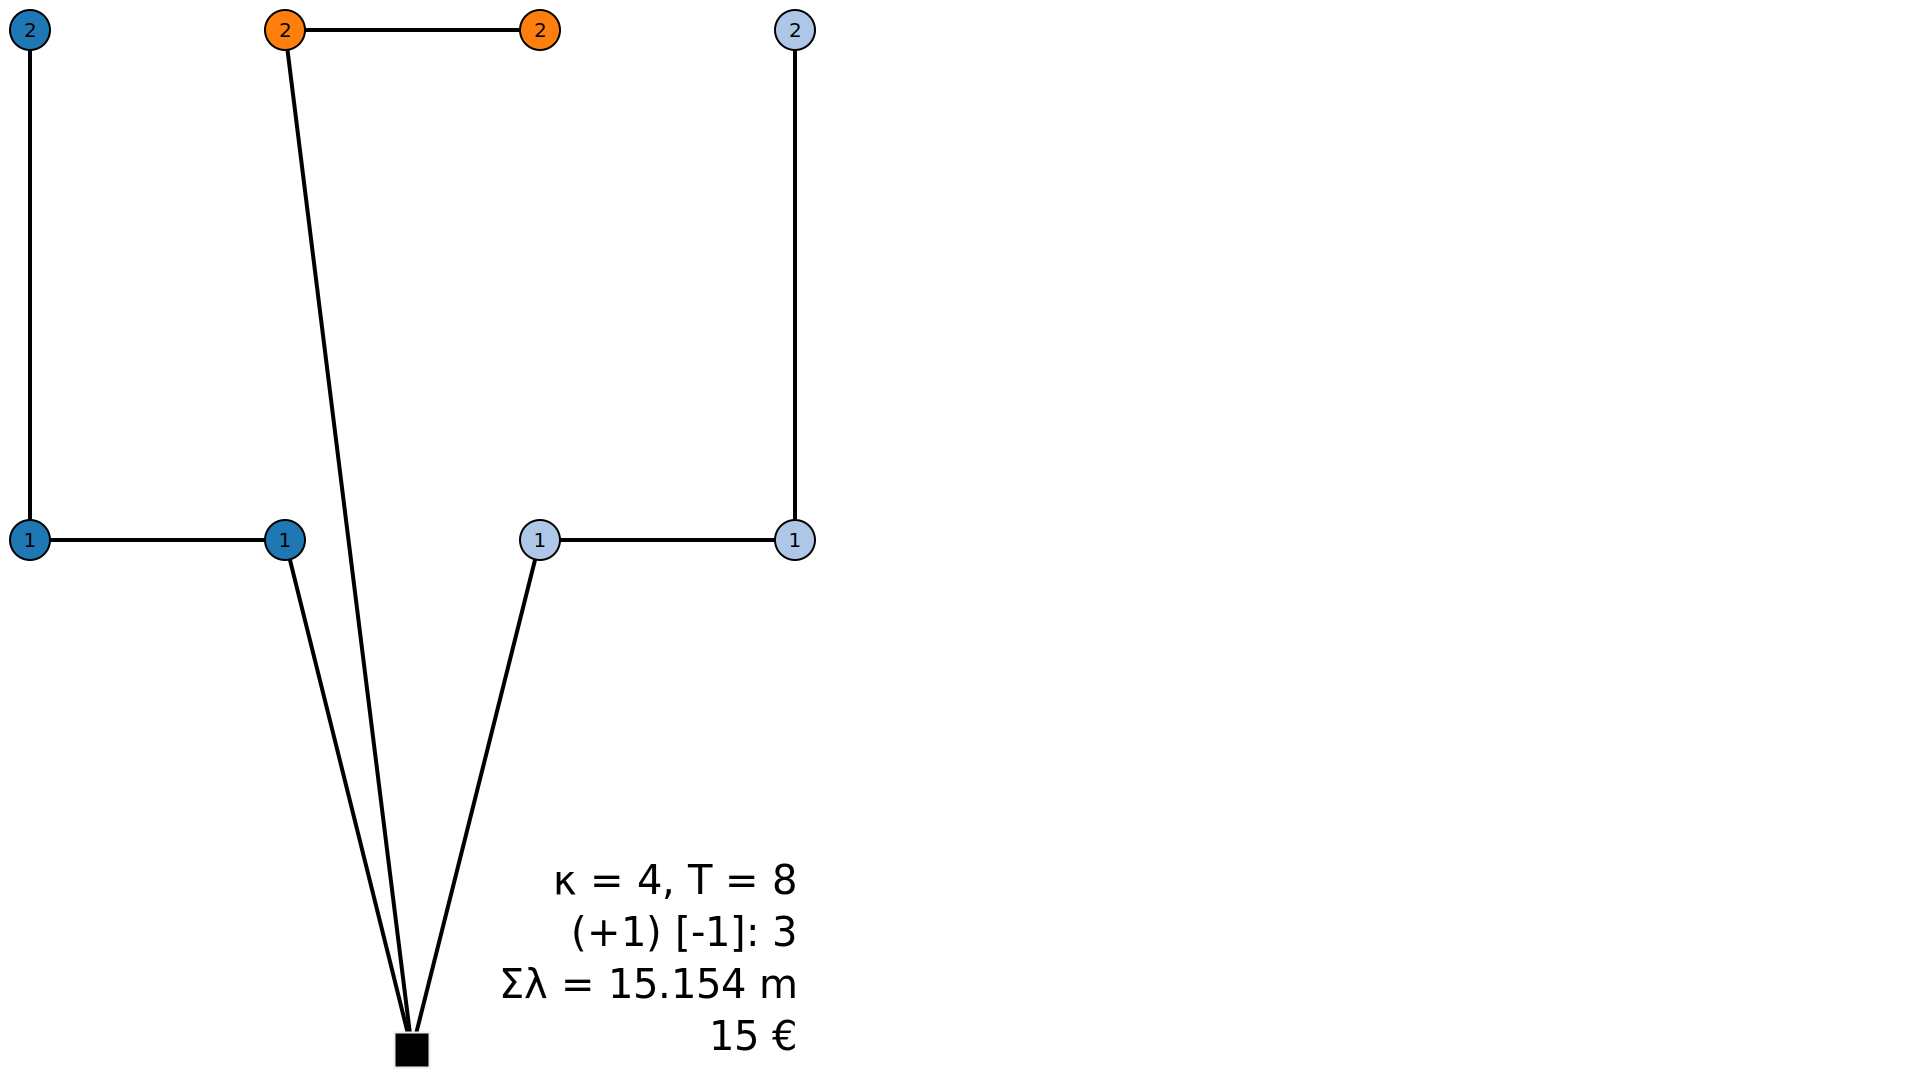

In [6]:
wfn_weighted = WindFarmNetwork(
    cables=[(4, 1.0)],
    turbinesC=turbinesC,
    substationsC=substationsC,
    turbine_power=turbine_power,
    router=MILPRouter('ortools', time_limit=60, mip_gap=0.01),
)
wfn_weighted.optimize()
wfn_weighted.plot(node_tag='power')

Cable loads in the weighted case (high-power turbines contribute 2 units each):

In [7]:
for u, v, data in sorted(wfn_weighted.G.edges(data=True)):
    if 'load' in data:
        print(f'{u:>3} -> {v:>3}  load={data["load"]:.1f}')

 -1 ->   1  load=4.0
 -1 ->   2  load=4.0
 -1 ->   5  load=4.0
  0 ->   1  load=3.0
  0 ->   4  load=2.0
  3 ->   2  load=3.0
  3 ->   7  load=2.0
  6 ->   5  load=2.0


> **Why is the total cable length longer?**

The uniform solution is actually **not feasible** under the real power constraints. 
If turbines 4–7 genuinely produce twice the nominal power, a cable carrying even two of them 
already reaches the capacity limit of 4 power units — yet the uniform optimizer ignored this 
and grouped them freely, producing a shorter but physically invalid design.

The weighted optimizer correctly enforces that no cable exceeds 4 power units of flow. 
This forces high-power turbines onto separate feeders, which may be geometrically farther apart, 
resulting in longer cable runs. The longer network is therefore the correct feasible solution — 
the uniform one would require oversized cables in practice.

The reverse is also true: if the last 4 turbines have **lower** rated power, each feeder can carry more of them within the same cable capacity, giving the optimizer more freedom and typically producing a shorter, cheaper network.

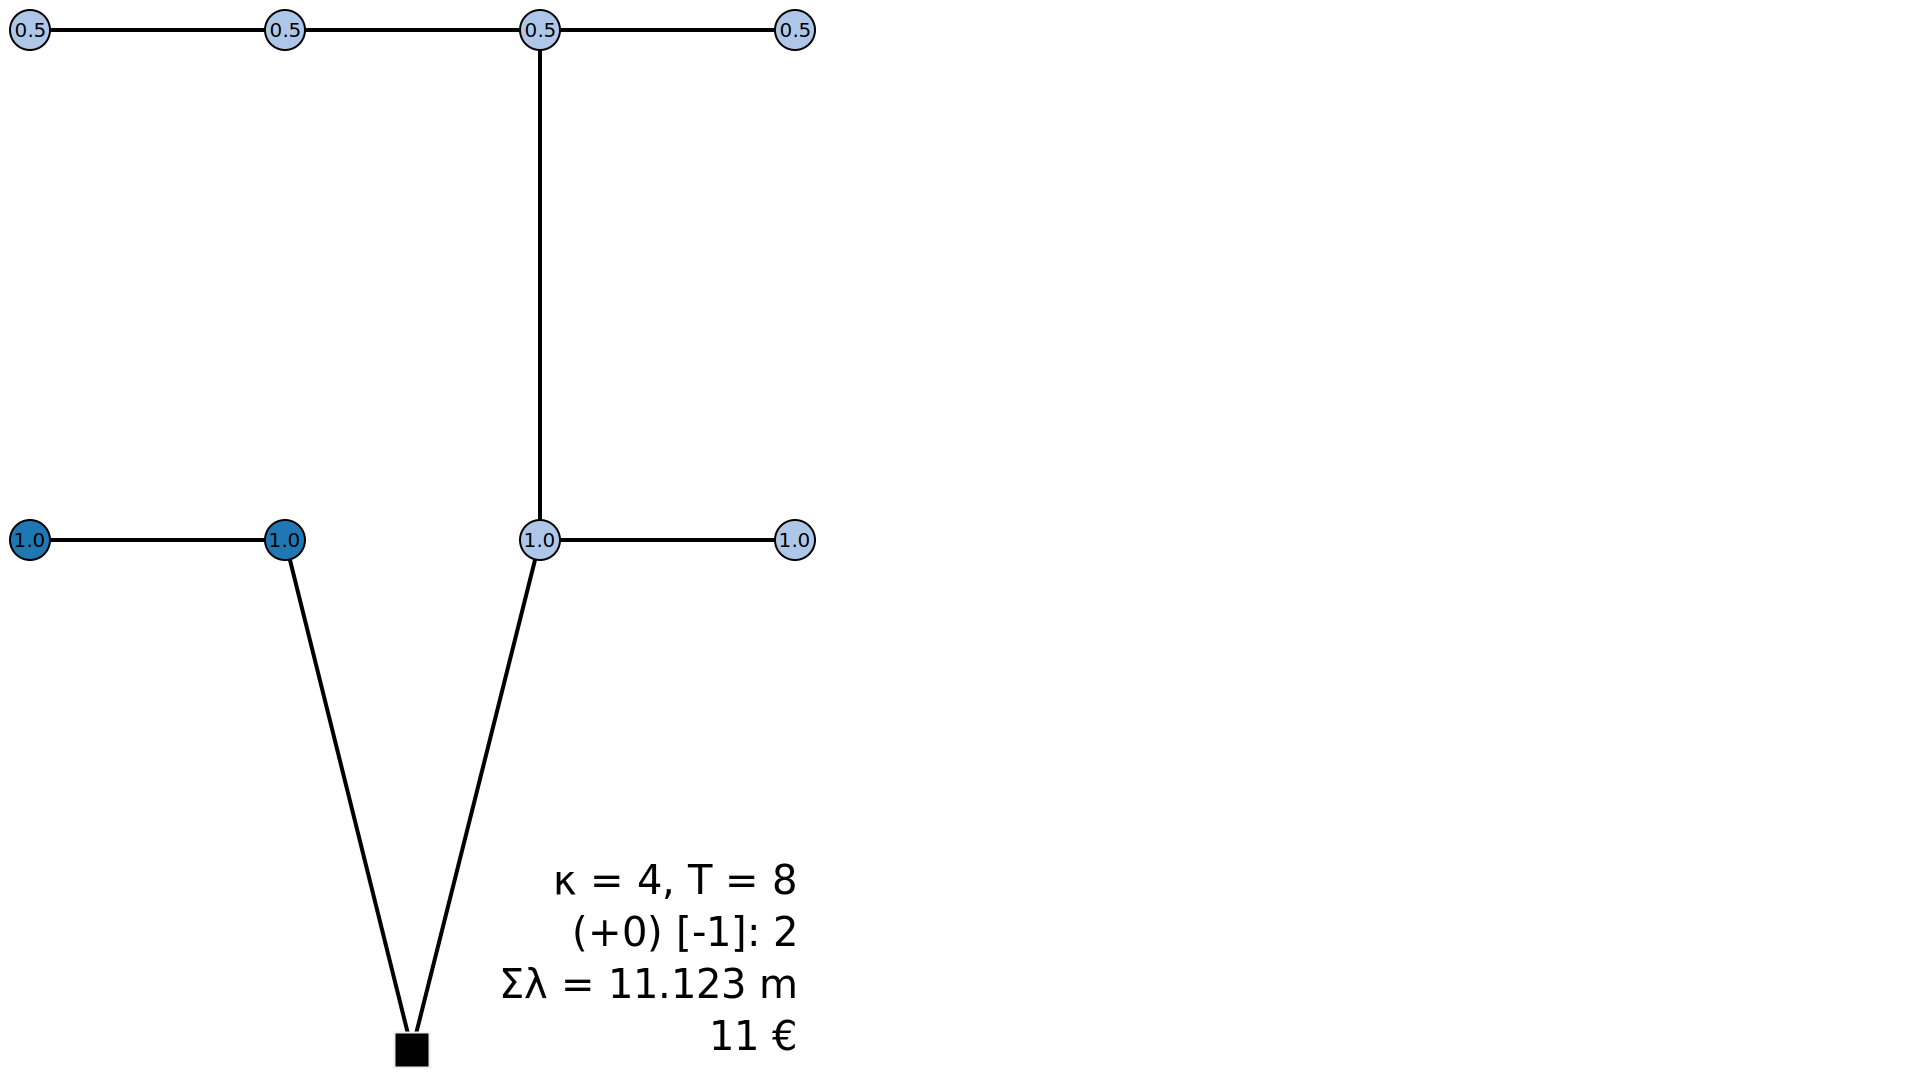

In [8]:
wfn_low = WindFarmNetwork(
    cables=[(4, 1.0)],
    turbinesC=turbinesC,
    substationsC=substationsC,
    turbine_power=[1.0, 1.0, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5],
    router=MILPRouter('ortools', time_limit=60, mip_gap=0.01),
)
wfn_low.optimize()
wfn_low.plot(node_tag='power')

In [9]:
print(f'Uniform  total length: {wfn_uniform.length():_.0f}')
print(f'Weighted (high) total length: {wfn_weighted.length():_.0f}')
print(f'Weighted (low)  total length: {wfn_low.length():_.0f}')

Uniform  total length: 12
Weighted (high) total length: 15
Weighted (low)  total length: 11


## Warning: Heuristic Routers

`EWRouter` and `HGSRouter` do not support non-uniform power. 
Calling `optimize()` with `turbine_power` set and a heuristic router raises a `TypeError`.

In [10]:
try:
    wfn_ew = WindFarmNetwork(
        cables=[(4, 1.0)],
        turbinesC=turbinesC,
        substationsC=substationsC,
        turbine_power=turbine_power,
        router=EWRouter(),
    )
    wfn_ew.optimize()
except TypeError as e:
    print(e)

EWRouter does not support non-uniform turbine_power. Use MILPRouter for weighted power optimization.


## Power Scale and Performance

Internally, OptiWindNet converts float power values to integers by finding the least common multiple (LCM) of their denominators. This **scale factor** determines how much the cable capacity and flow domains expand inside the MILP model.

A larger scale factor means larger integer domains for flow variables, which can make the solver work harder. The table below shows the scale for common ratios:

In [11]:
from optiwindnet.api import _normalize_turbine_power

examples = [
    ('Integer ratios  [1, 2, 3]',      [1,    2,    3   ]),
    ('Simple halves   [1.0, 0.5]',     [1.0,  0.5       ]),
    ('Quarters        [1.0, 0.75]',    [1.0,  0.75      ]),
    ('Thirds          [1.0, 1/3]',     [1.0,  1/3       ]),
    ('Mixed           [1.0, 1.5, 2.0]',[1.0,  1.5,  2.0 ]),
    ('Scale 5         [1.0, 0.4]',     [1.0,  0.4       ]),
    ('Scale 10        [1.0, 0.1]',     [1.0,  0.1       ]),
    ('Scale 20        [1.0, 0.05]',    [1.0,  0.05      ]),
    ('Scale 50        [1.0, 0.02]',    [1.0,  0.02      ]),
    ('Scale 70        [1.0, 1/70]',    [1.0,  1/70      ]),
    ('High precision  [1.0, 1.01]',    [1.0,  1.01      ]),
    ('High precision  [1.0, 1.001]',   [1.0,  1.001     ]),
]

print(f'{'Example':<35} {'int powers':<25} scale')
print('-' * 65)
for label, powers in examples:
    T = len(powers)
    int_p, scale = _normalize_turbine_power(powers, T)
    print(f'{label:<35} {str(int_p):<25} {scale}')

turbine_power normalization scale factor is 20. Large scale factors may slow down MILP optimization.
turbine_power normalization scale factor is 50. Large scale factors may slow down MILP optimization.
turbine_power normalization scale factor is 70. Large scale factors may slow down MILP optimization.
turbine_power normalization scale factor is 100. Large scale factors may slow down MILP optimization.


Example                             int powers                scale
-----------------------------------------------------------------
Integer ratios  [1, 2, 3]           [1, 2, 3]                 1
Simple halves   [1.0, 0.5]          [2, 1]                    2
Quarters        [1.0, 0.75]         [4, 3]                    4
Thirds          [1.0, 1/3]          [3, 1]                    3
Mixed           [1.0, 1.5, 2.0]     [2, 3, 4]                 2
Scale 5         [1.0, 0.4]          [5, 2]                    5
Scale 10        [1.0, 0.1]          [10, 1]                   10
Scale 20        [1.0, 0.05]         [20, 1]                   20
Scale 50        [1.0, 0.02]         [50, 1]                   50
Scale 70        [1.0, 1/70]         [70, 1]                   70
High precision  [1.0, 1.01]         [100, 101]                100
High precision  [1.0, 1.001]        [1, 1]                    1


**Key observations:**

* Simple integer ratios and common fractions (1/2, 1/4, 3/4) produce a small scale (≤ 4) with negligible performance impact.
* Values with many decimal places are **approximated** to the nearest fraction with denominator ≤ 100. For example, `1.001` rounds to `1/1` — effectively treated as equal to `1.0`. Always use exact fractions or simple decimals to avoid silent approximation.
* OptiWindNet emits a **warning** if the resulting scale exceeds 10.
* The practical per-value limit is a denominator of **100**. With multiple turbines having different fractional denominators the overall scale (their LCM) can exceed 100, so stick to simple ratios for best solver performance.

To illustrate the warning, here is an example that triggers it:

turbine_power normalization scale factor is 13. Large scale factors may slow down MILP optimization.


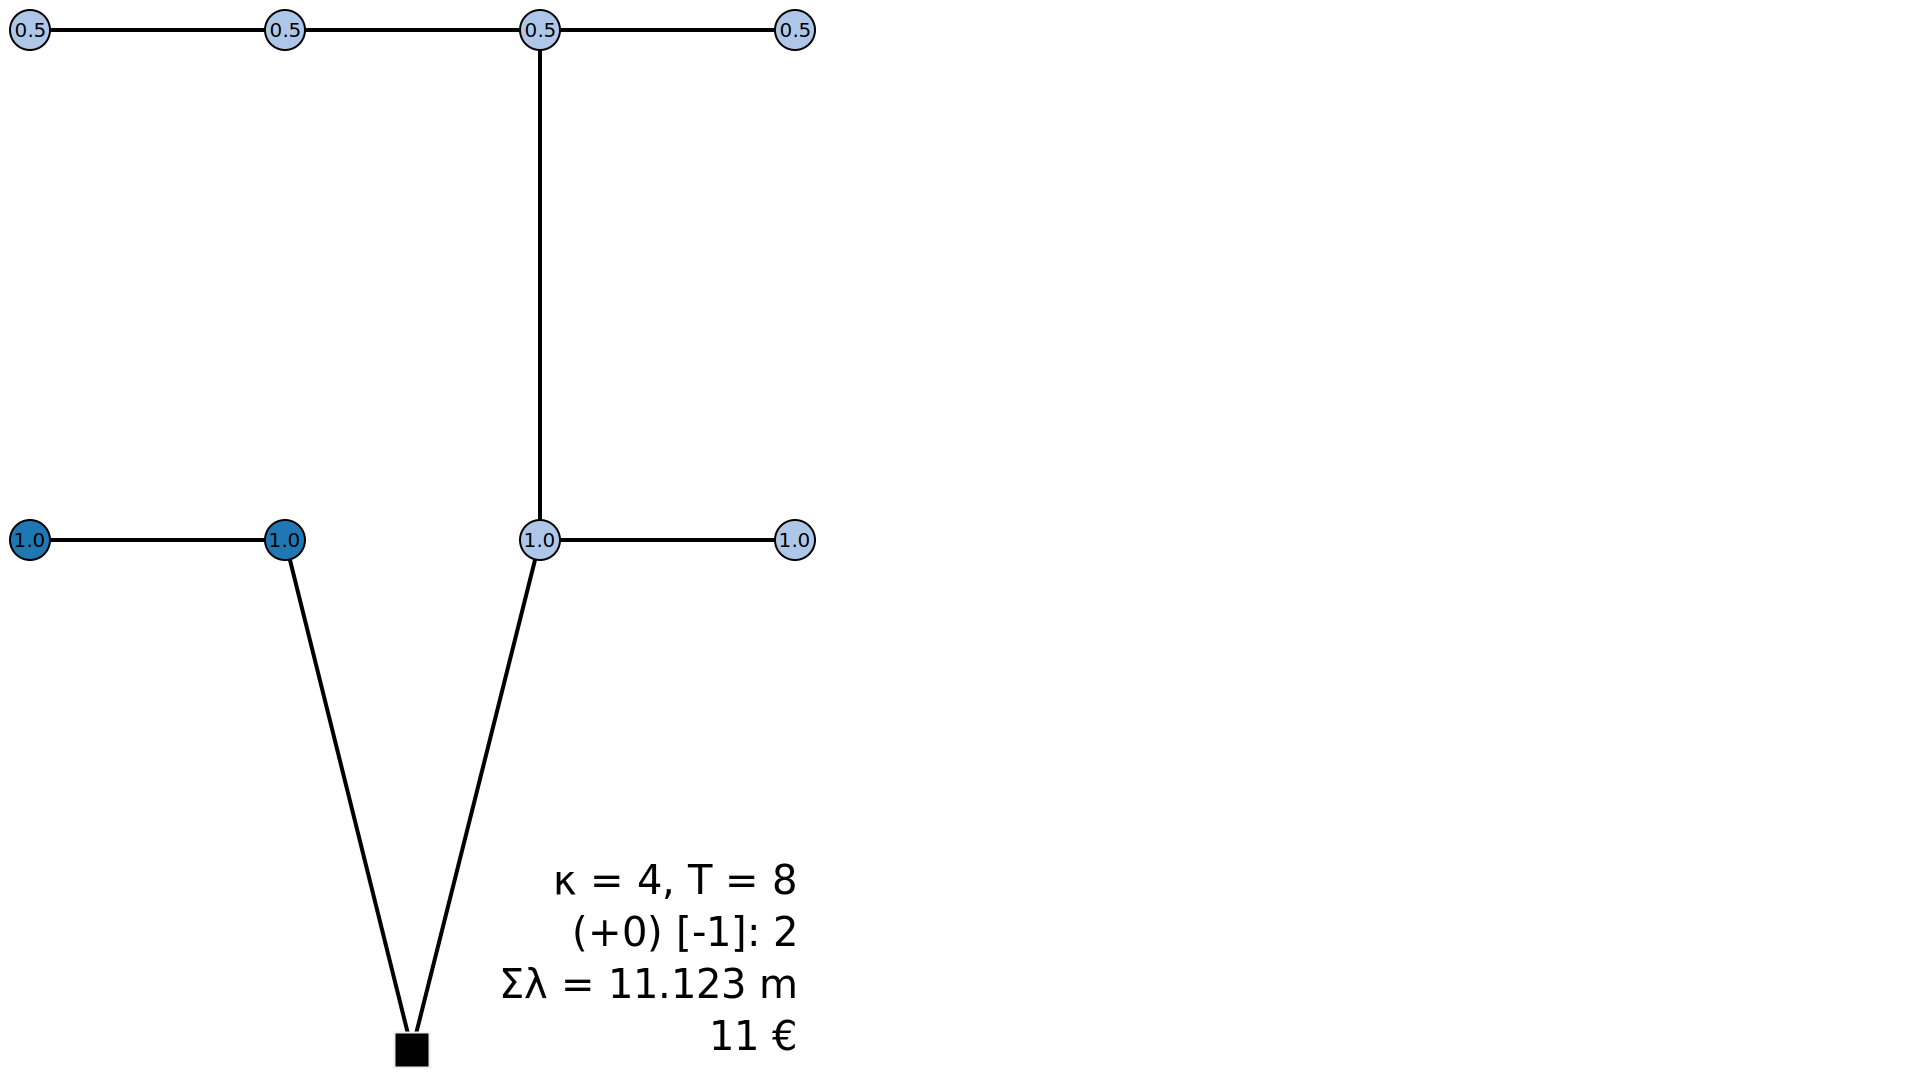

In [12]:
# Constructing with a large-scale factor triggers a logged warning
WindFarmNetwork(
    cables=[(4, 1.0)],
    turbinesC=turbinesC,
    substationsC=substationsC,
    turbine_power=[1.0, 1.0, 1.0, 1.0, 1/13, 1/13, 1/13, 1/13],
    router=MILPRouter('ortools', time_limit=60, mip_gap=0.01),
)

wfn_low.optimize()
wfn_low.plot(node_tag='power')

### Running Time vs. Scale Factor

The cell below times a single optimization run for four configurations on the **Ormonde** wind farm (T=30 turbines). Since MILP solving is stochastic, a single run is more representative than repeated averages that would benefit from warm-starting.

Note that the `[1.0, 2.0, ...]` case (scale=1) can still be slower than uniform power — not because of the scale factor, but because the non-uniform power distribution itself creates a harder, more constrained MILP. The scale factor is an *additional* source of slowdown on top of that.

[1.0, 1.0, ...]  scale=1     4.33 s


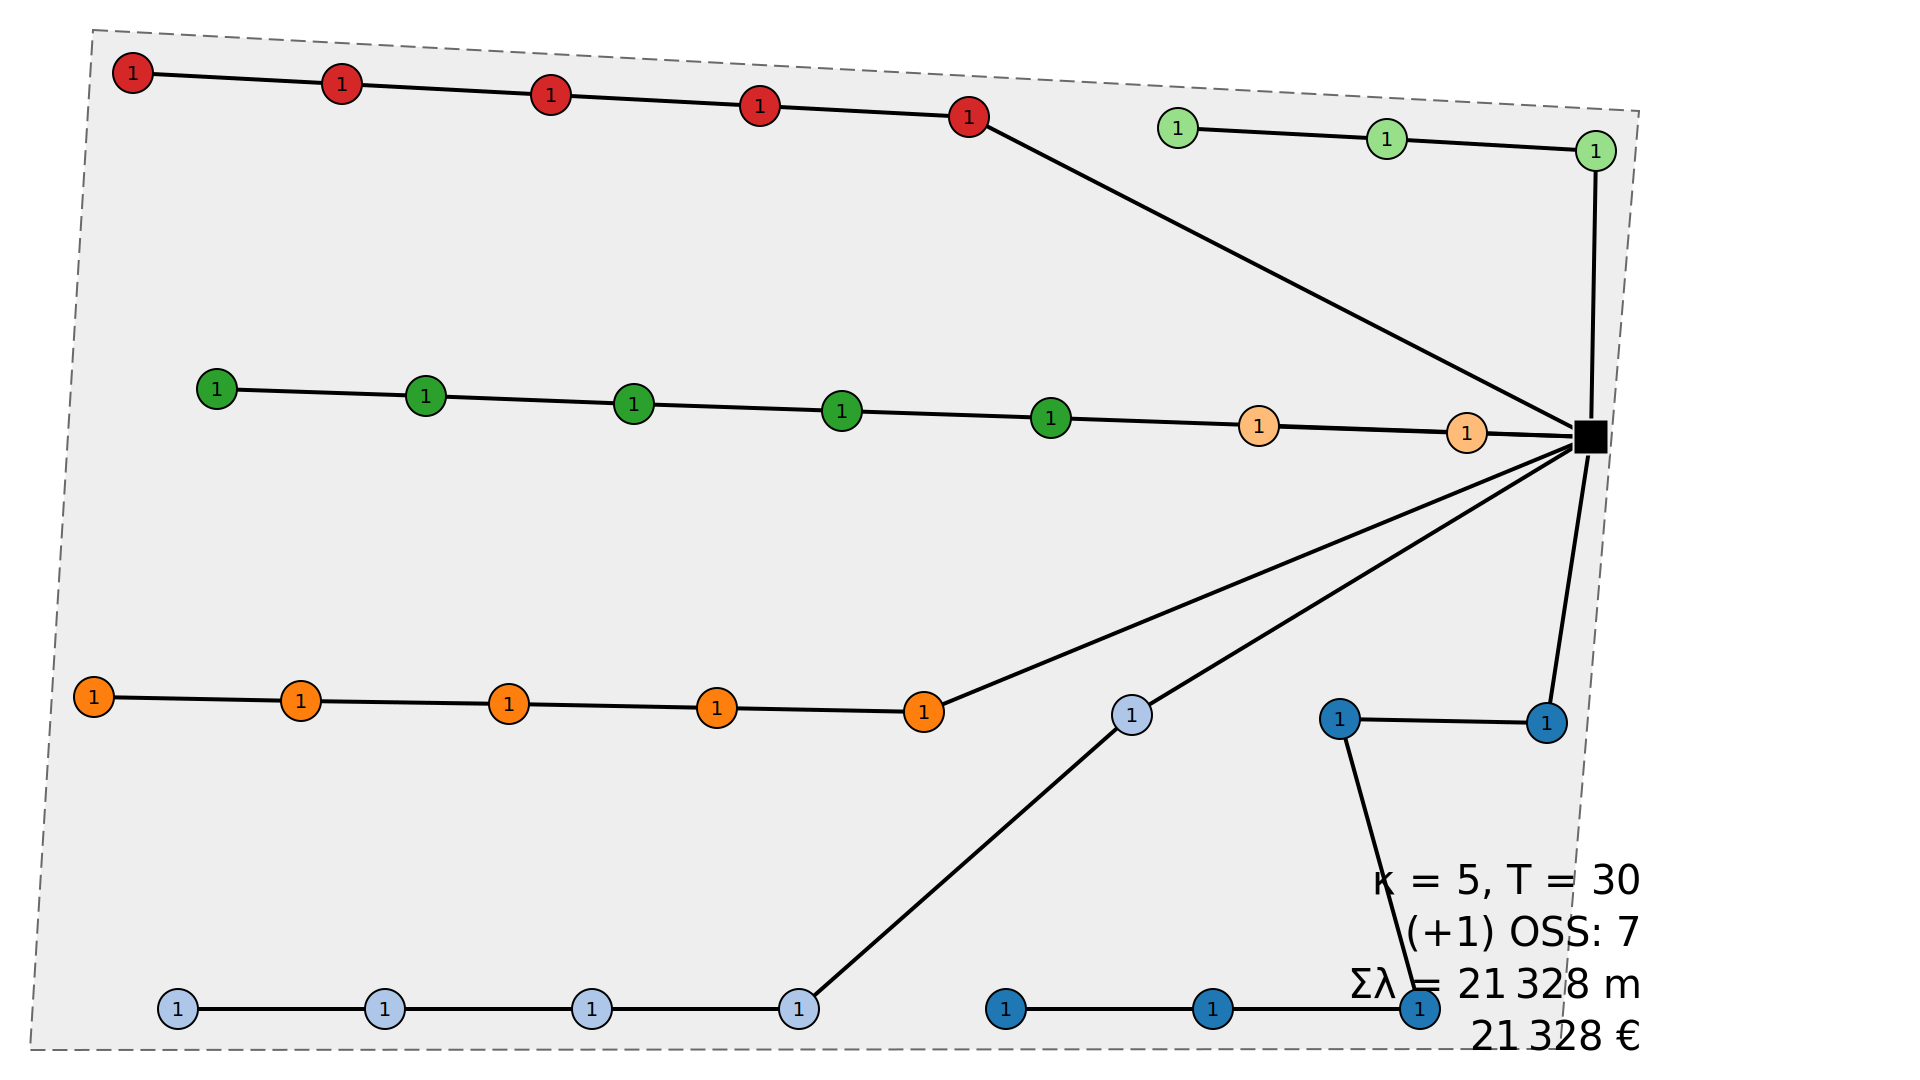

[1.0, 2.0, ...]  scale=1     11.70 s


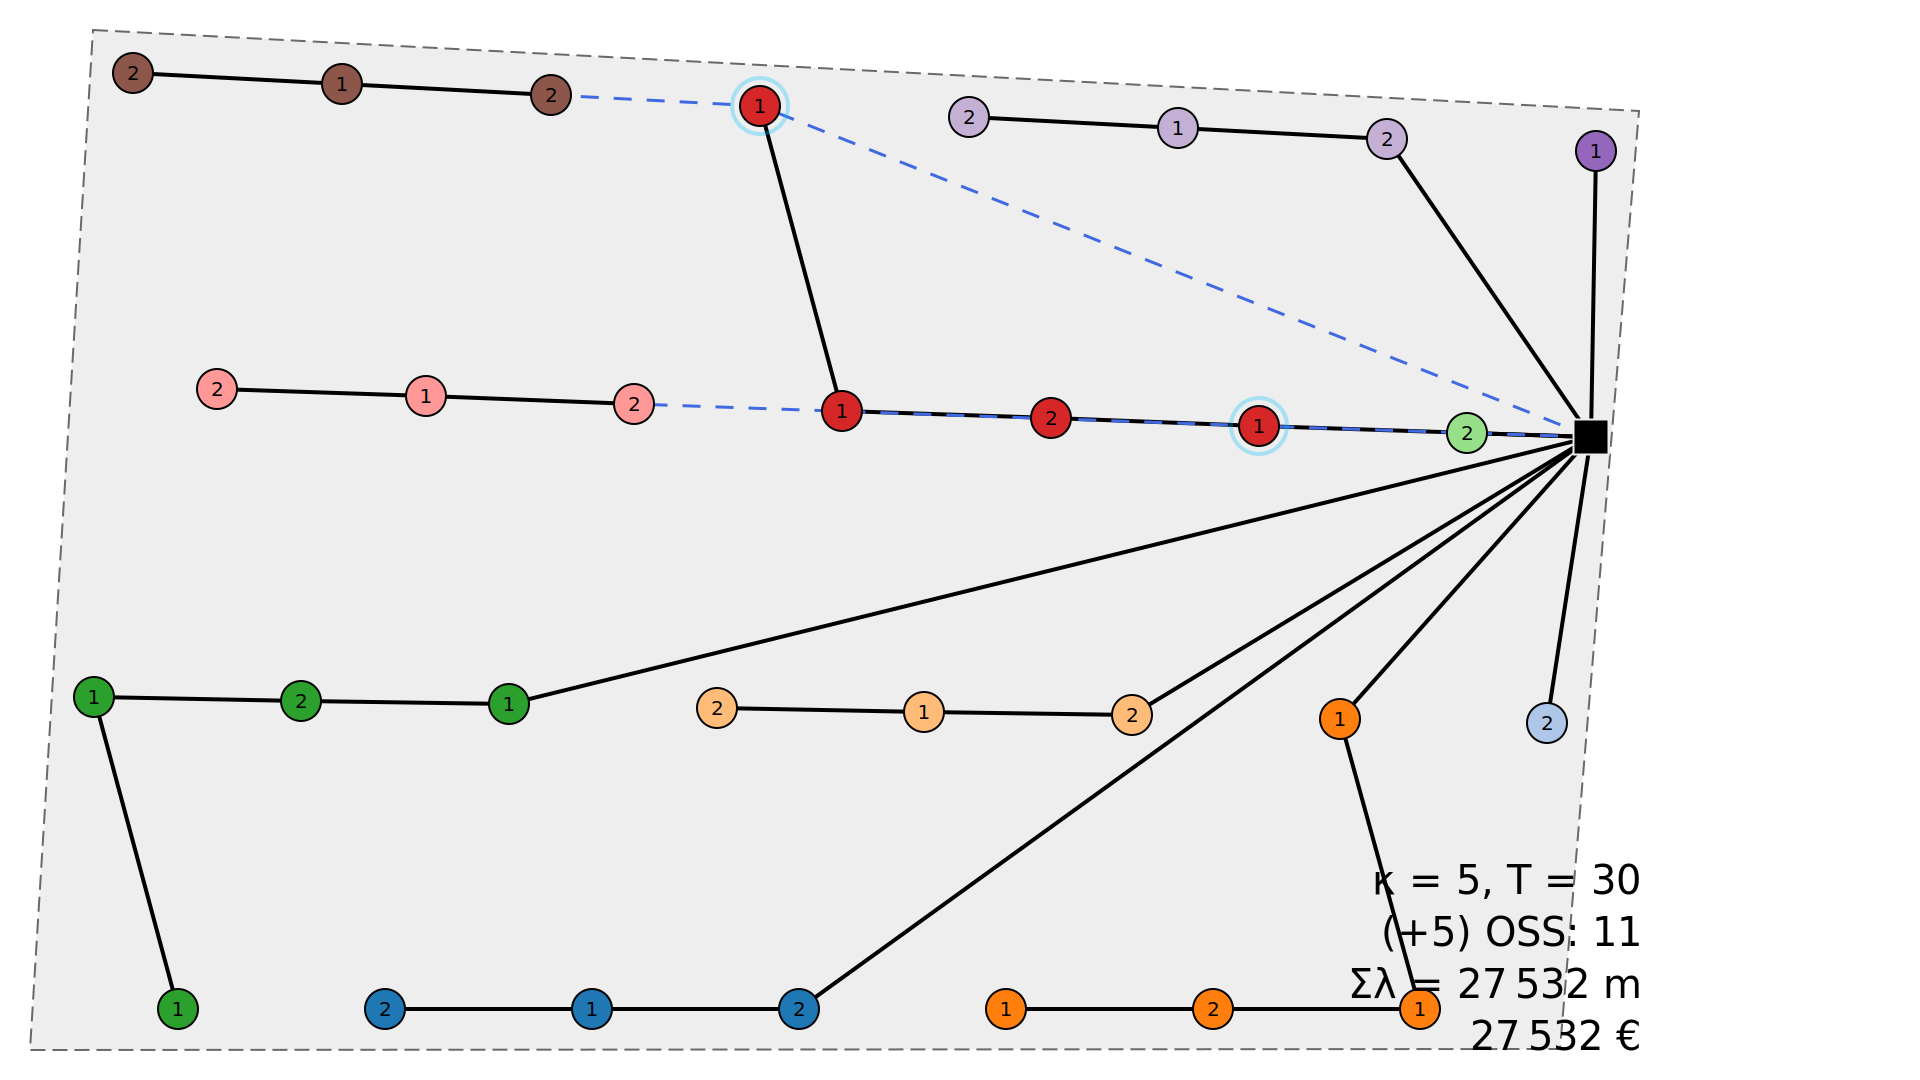

[1.0, 3, ...]  scale=1     3.27 s


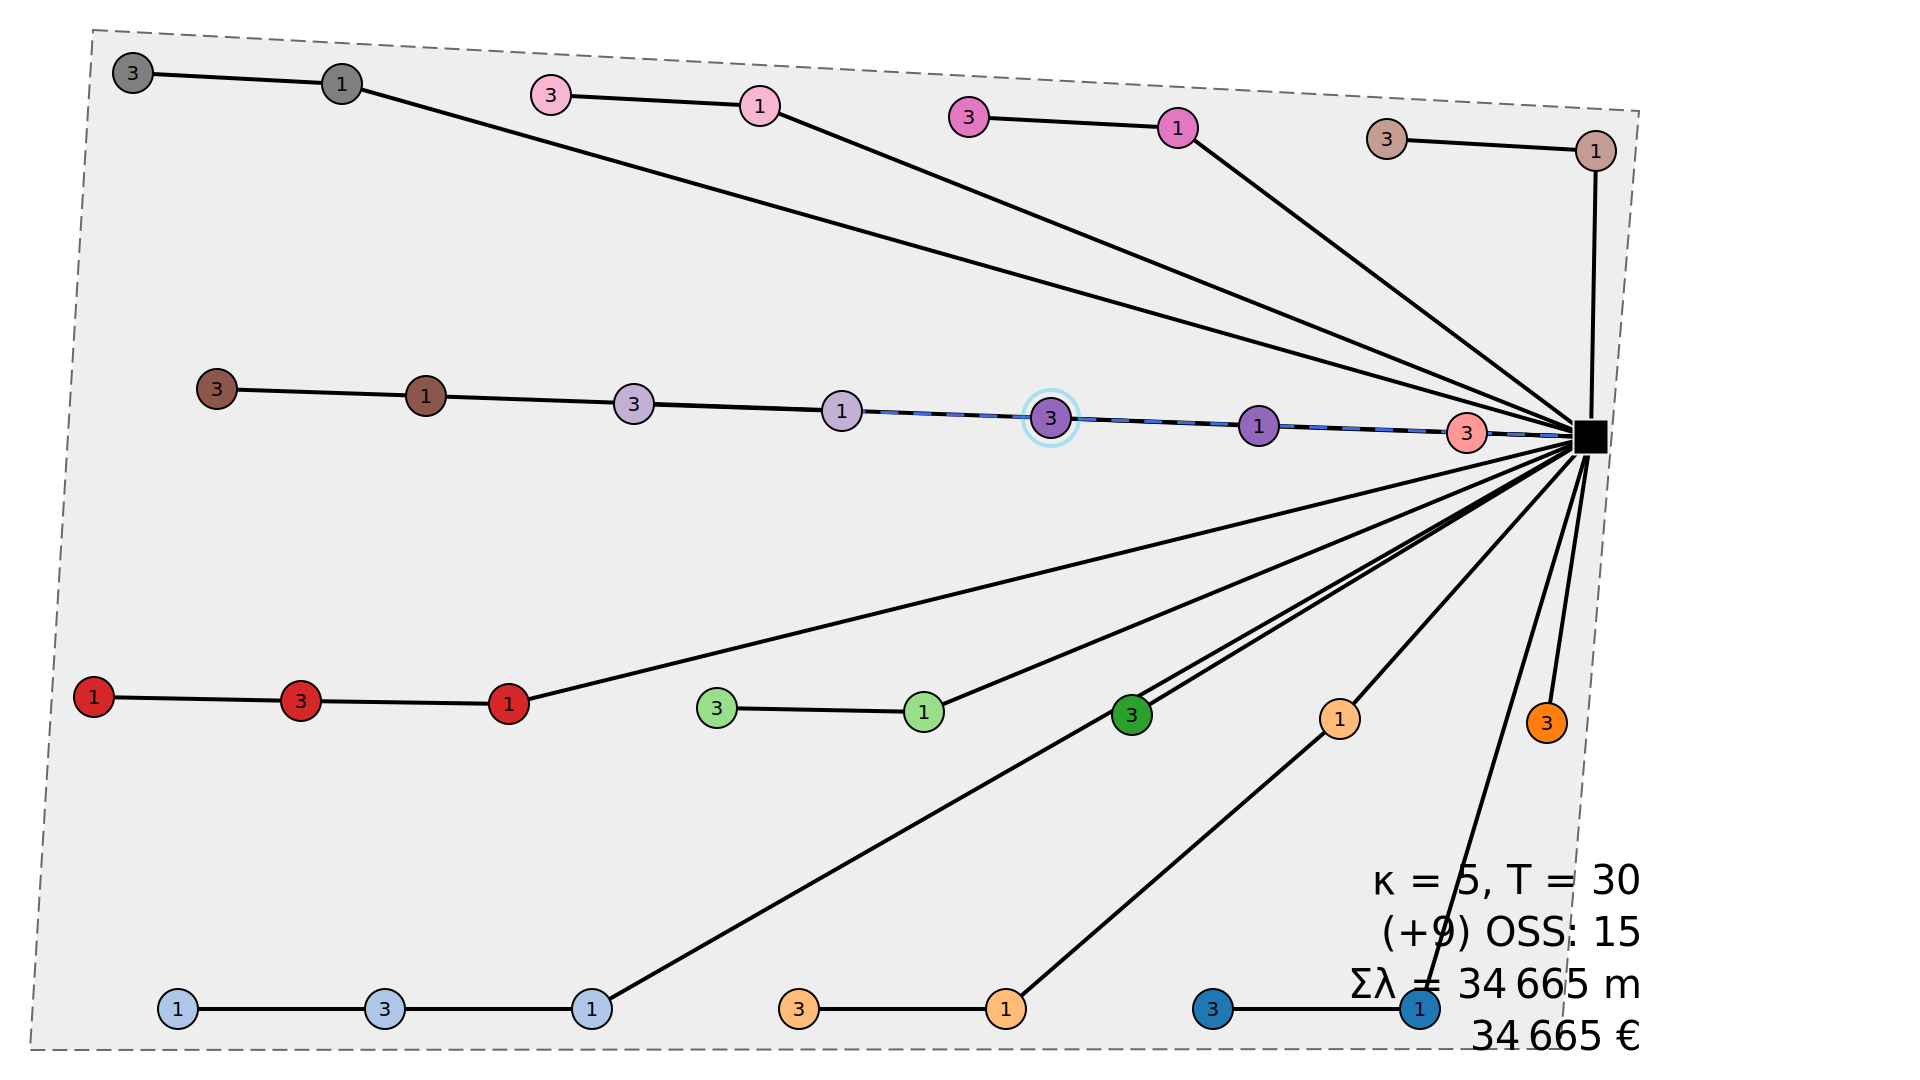

[1.0, 5, ...]  scale=1     0.19 s


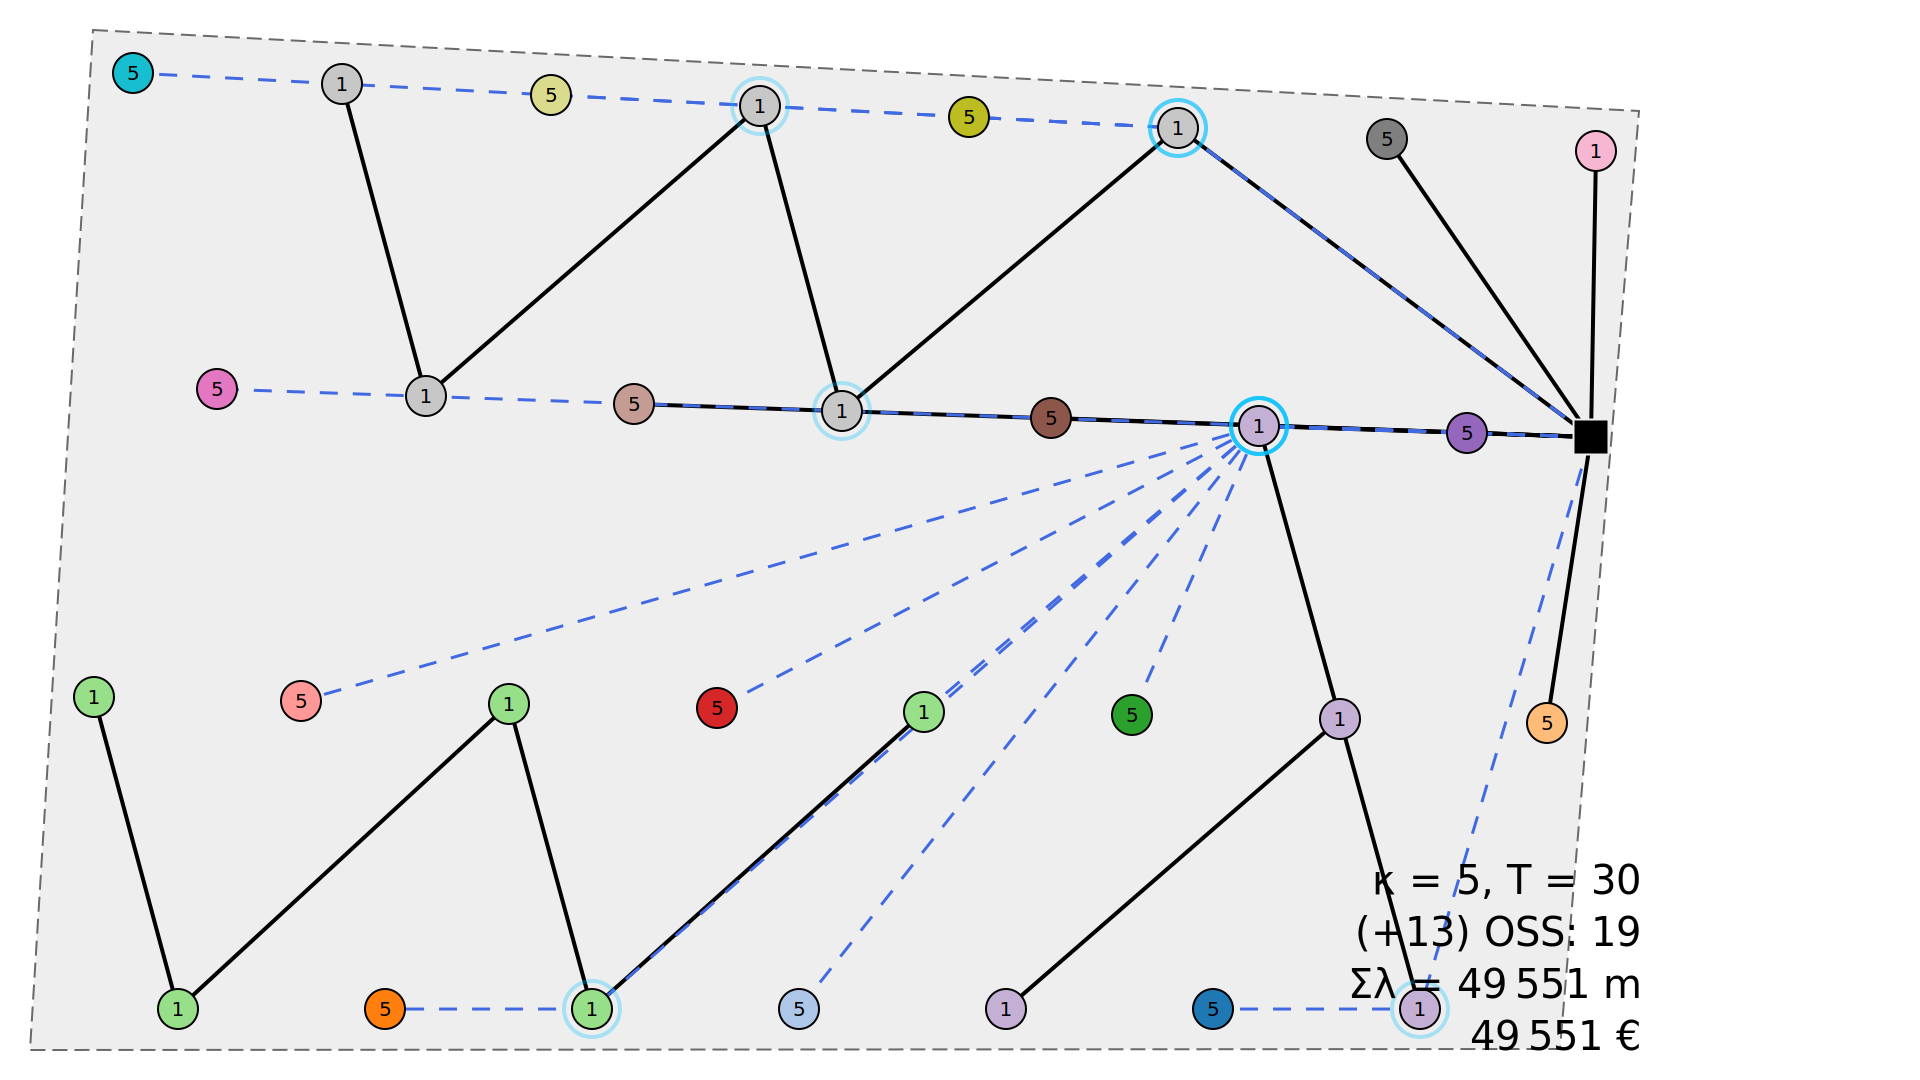

[1.0, 1.9, ...]  scale=10    60.05 s


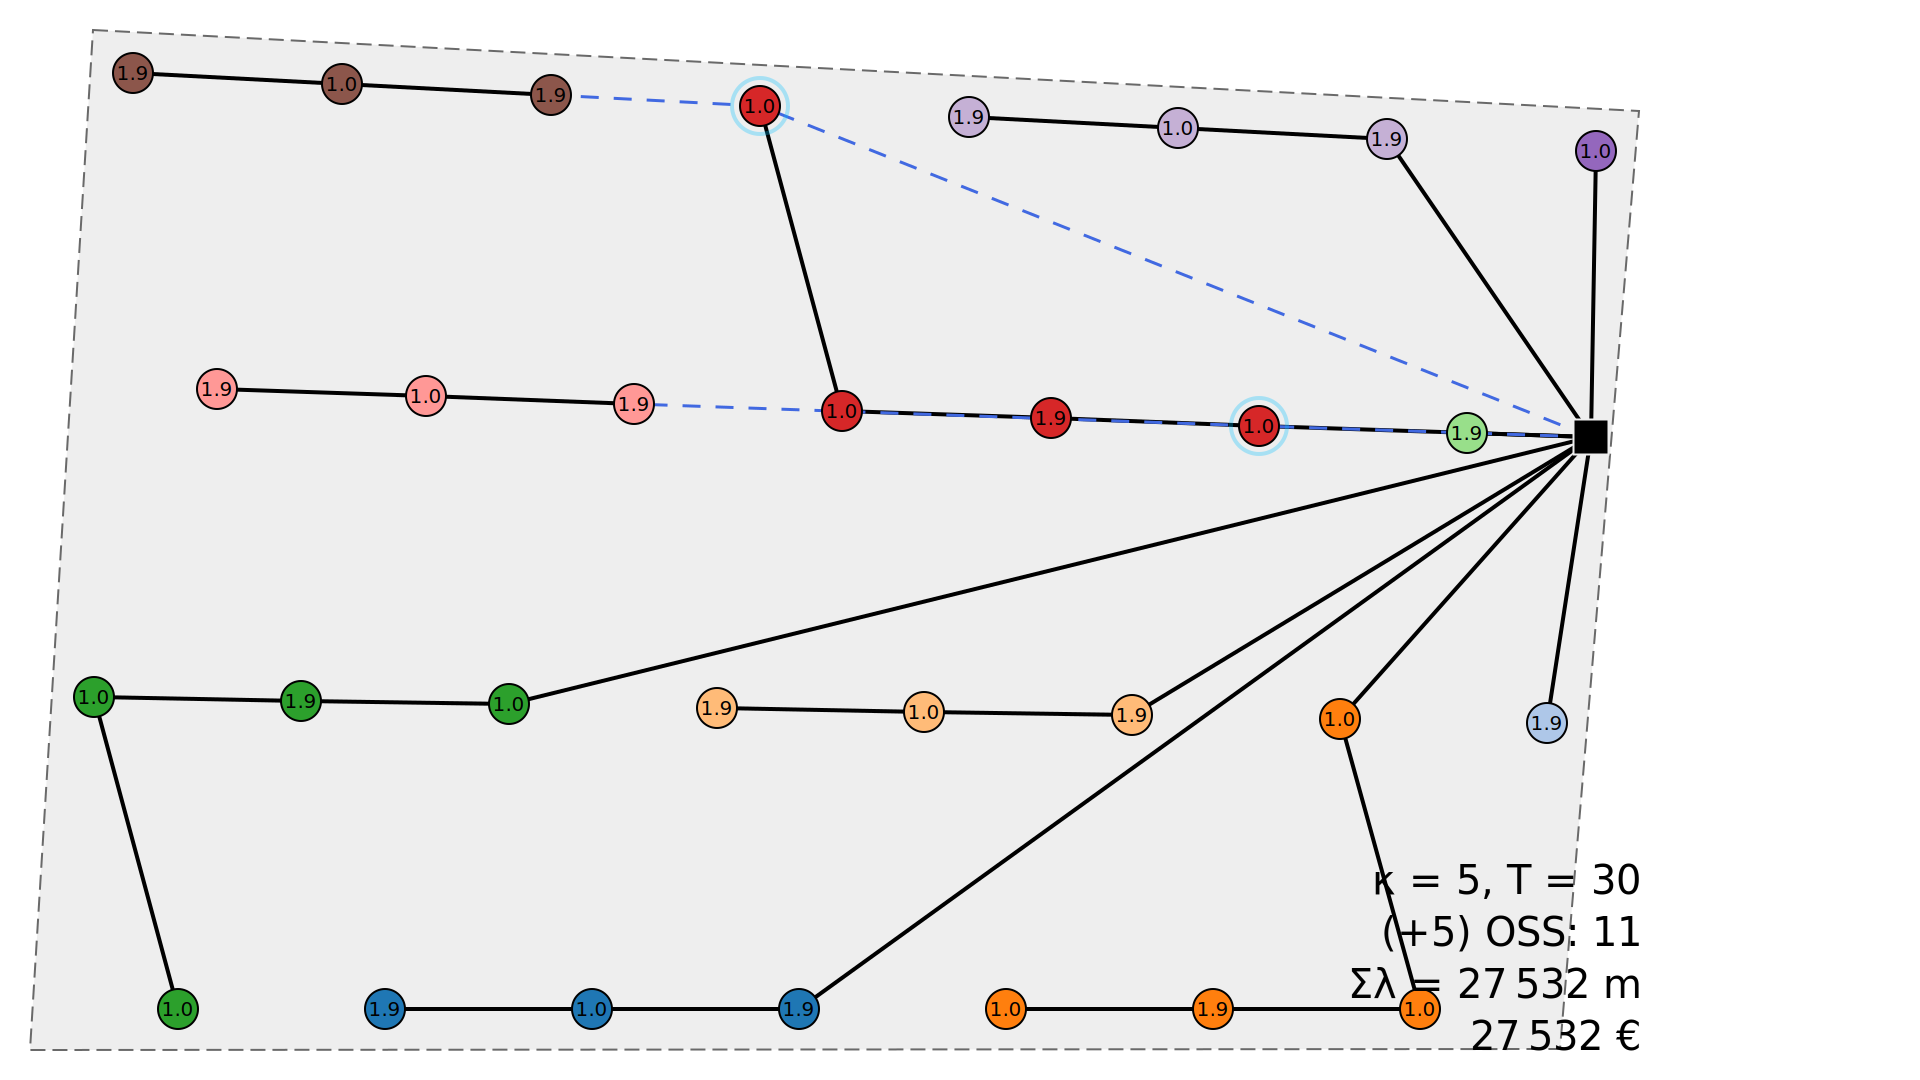

[1.0, 1.5, ...]  scale=2     1.19 s


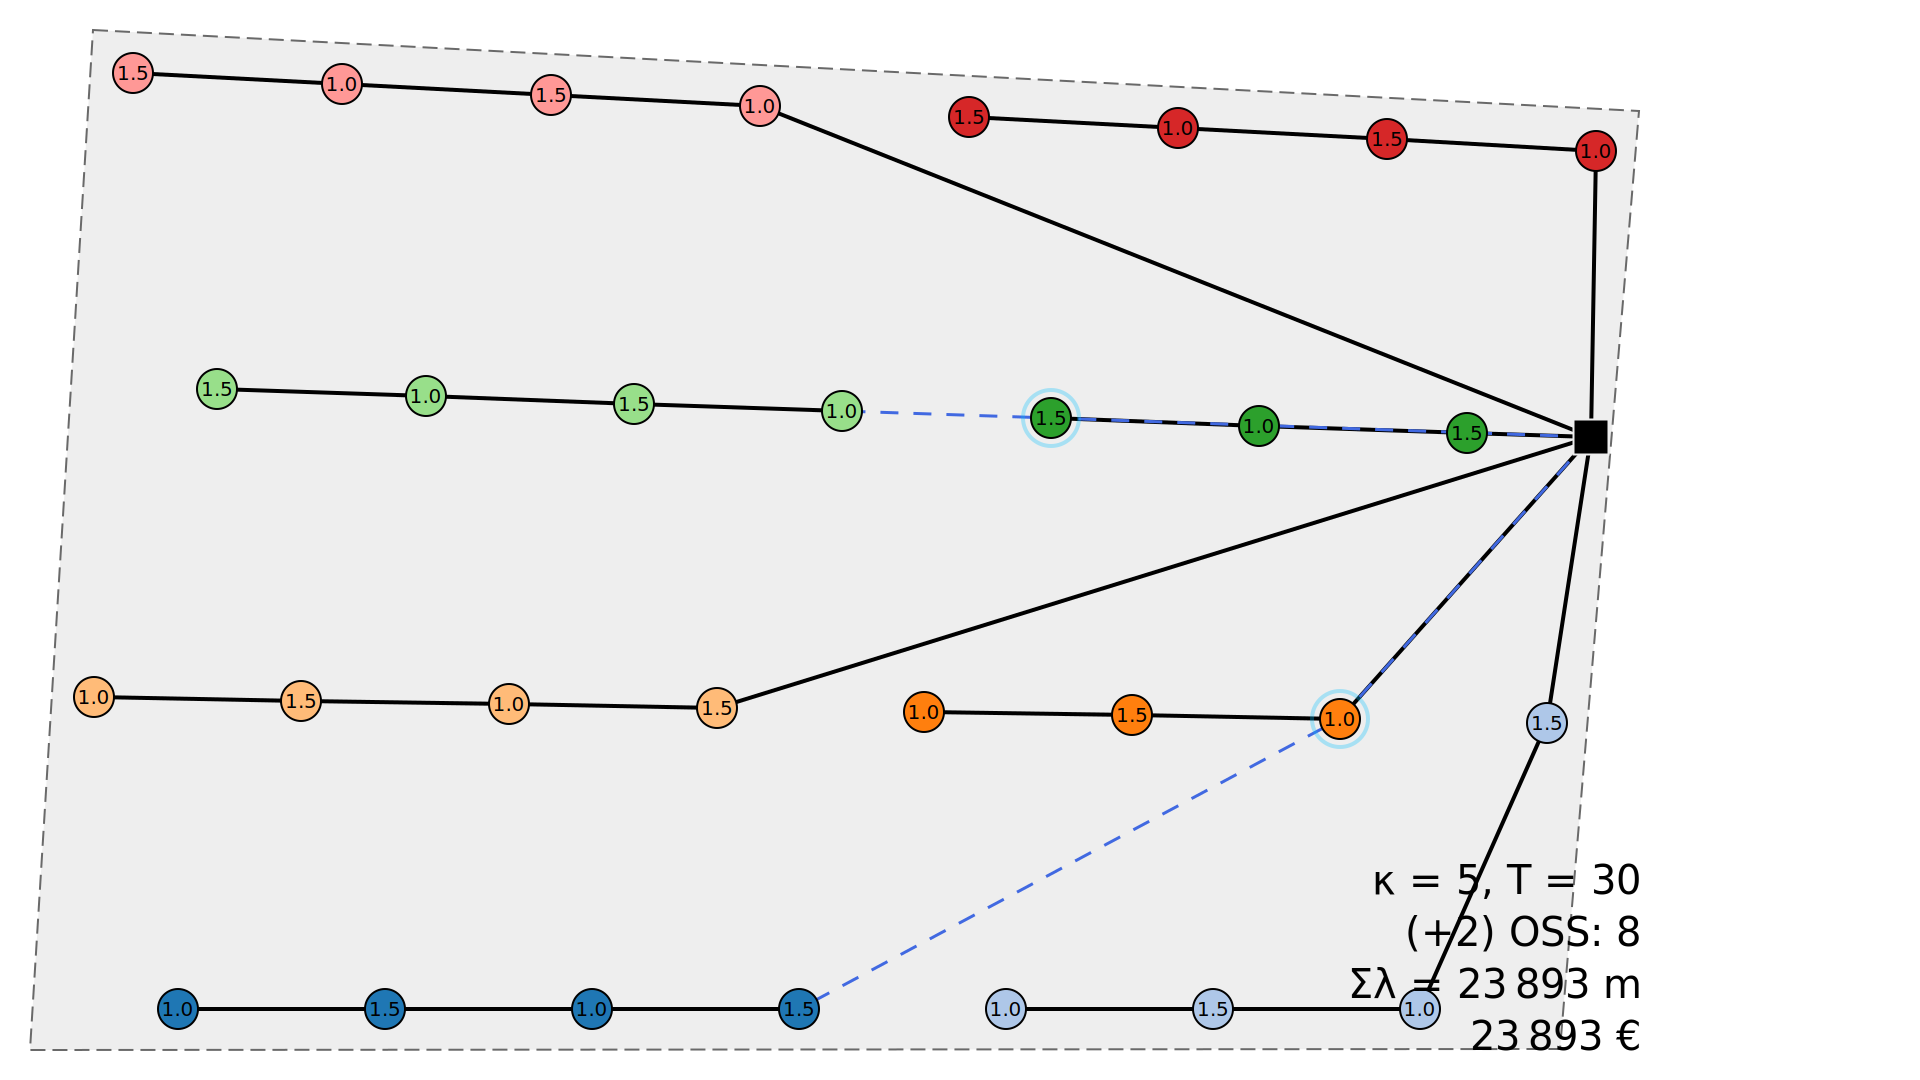

[1.0, 1.2, ...]  scale=5     60.11 s


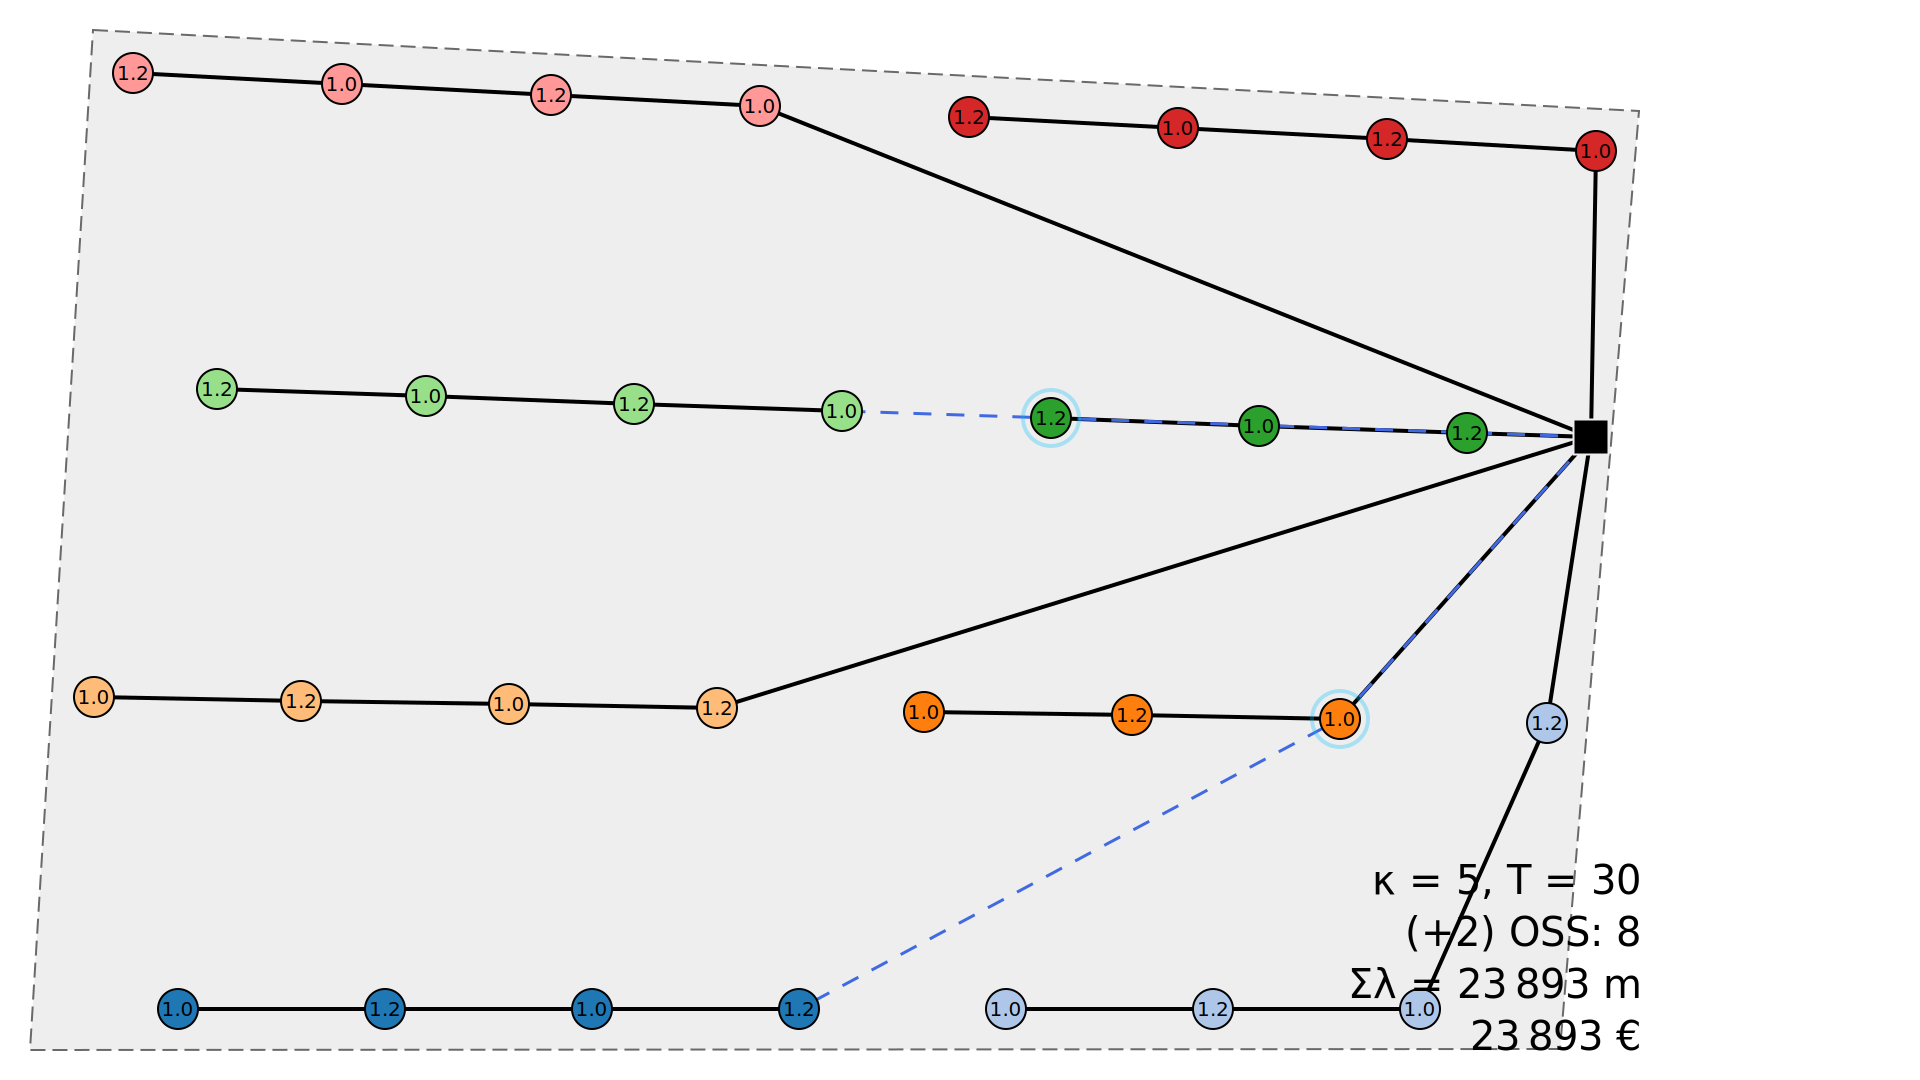

turbine_power normalization scale factor is 100. Large scale factors may slow down MILP optimization.
turbine_power normalization scale factor is 100. Large scale factors may slow down MILP optimization.


[1.0, 1.01, ...]  scale=100   60.10 s


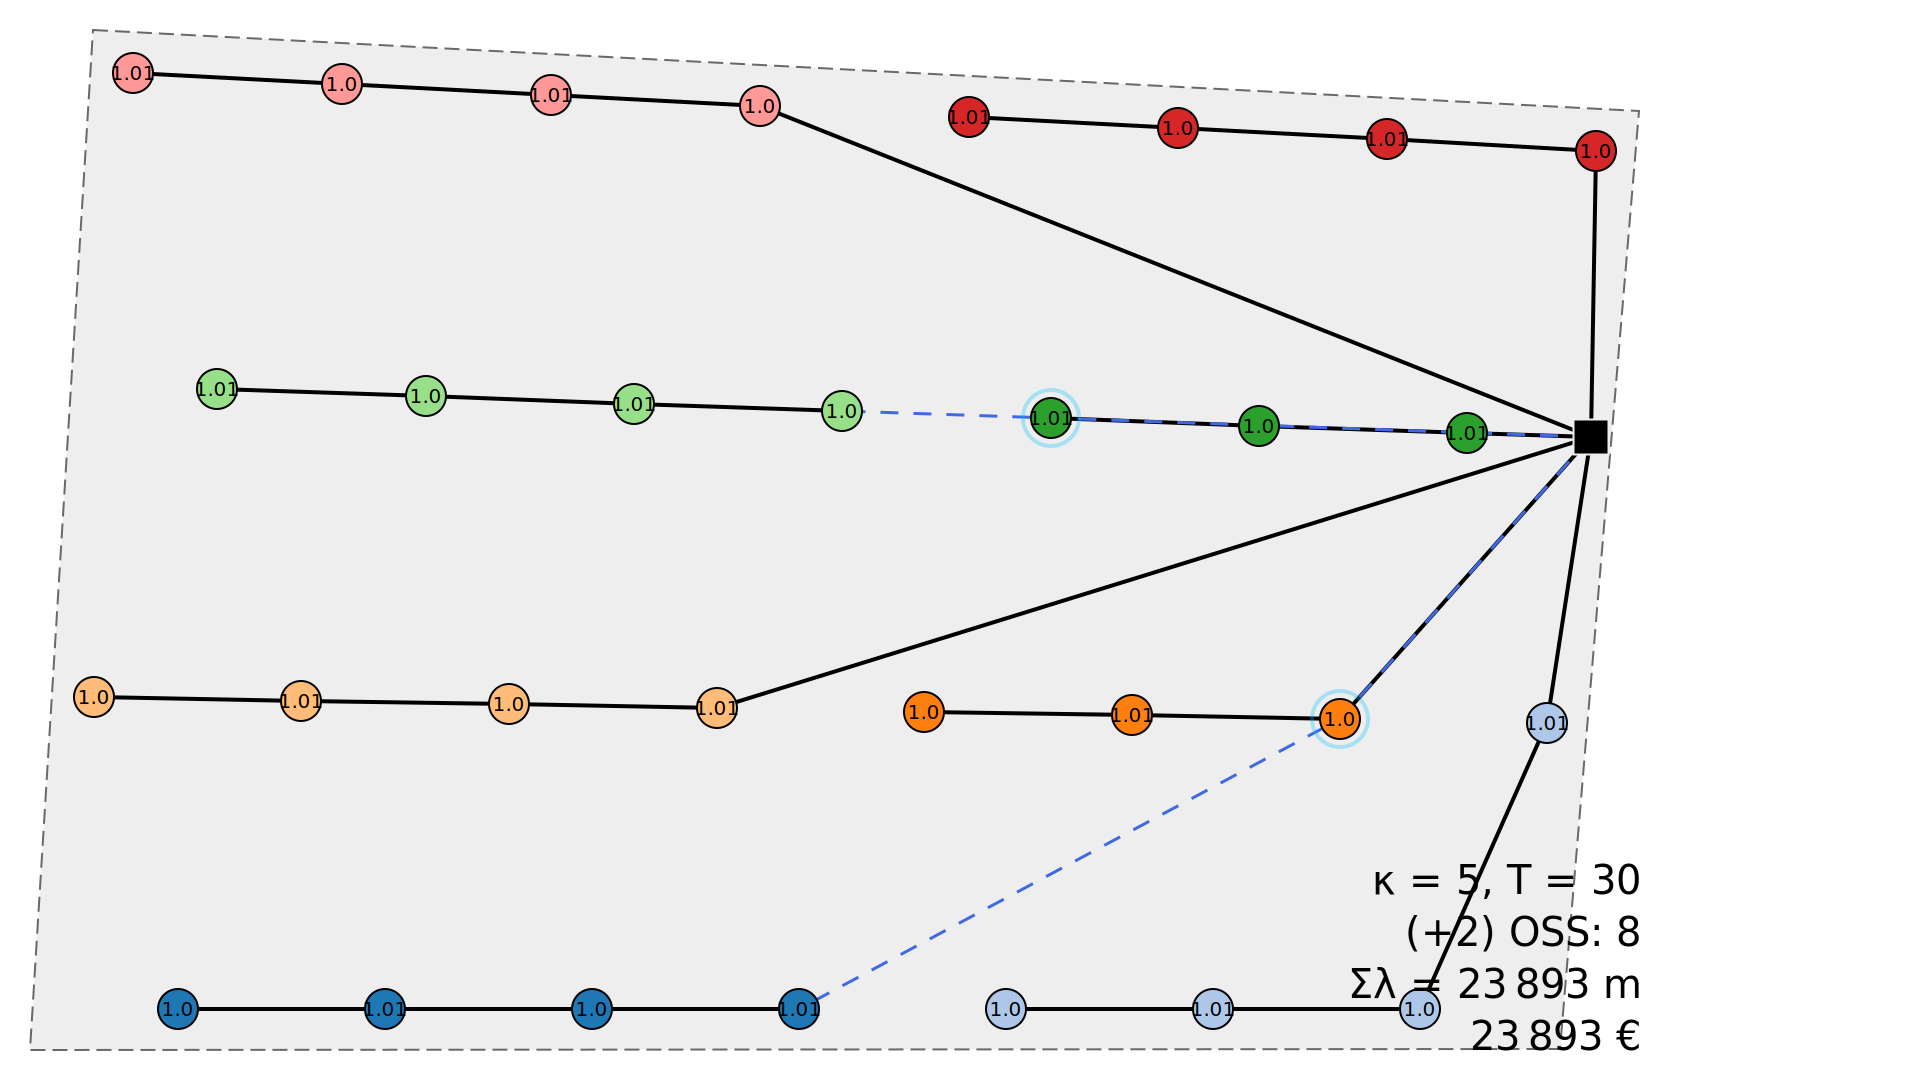

turbine_power normalization scale factor is 100. Large scale factors may slow down MILP optimization.
turbine_power normalization scale factor is 100. Large scale factors may slow down MILP optimization.


[1.0, 0.99, ...]  scale=100   5.78 s


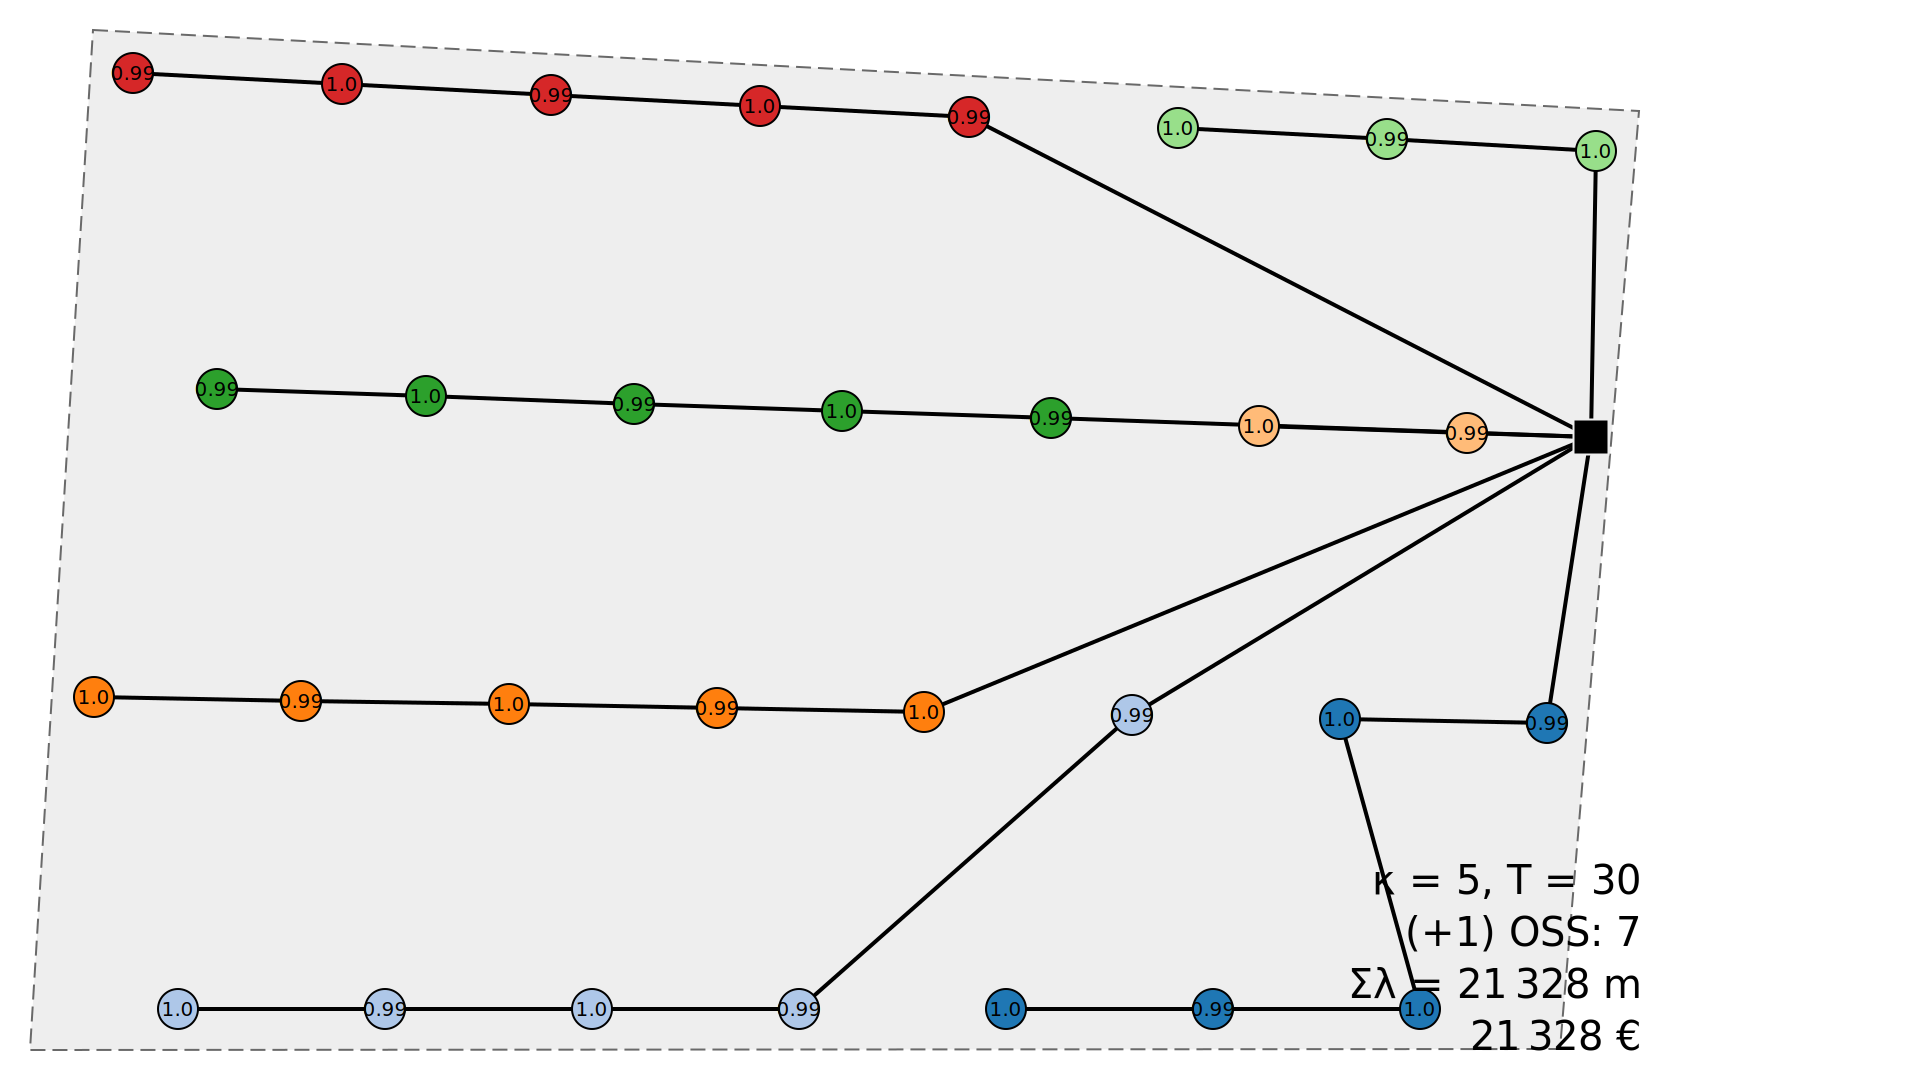

[1.0, 0.9, ...]  scale=10    22.50 s


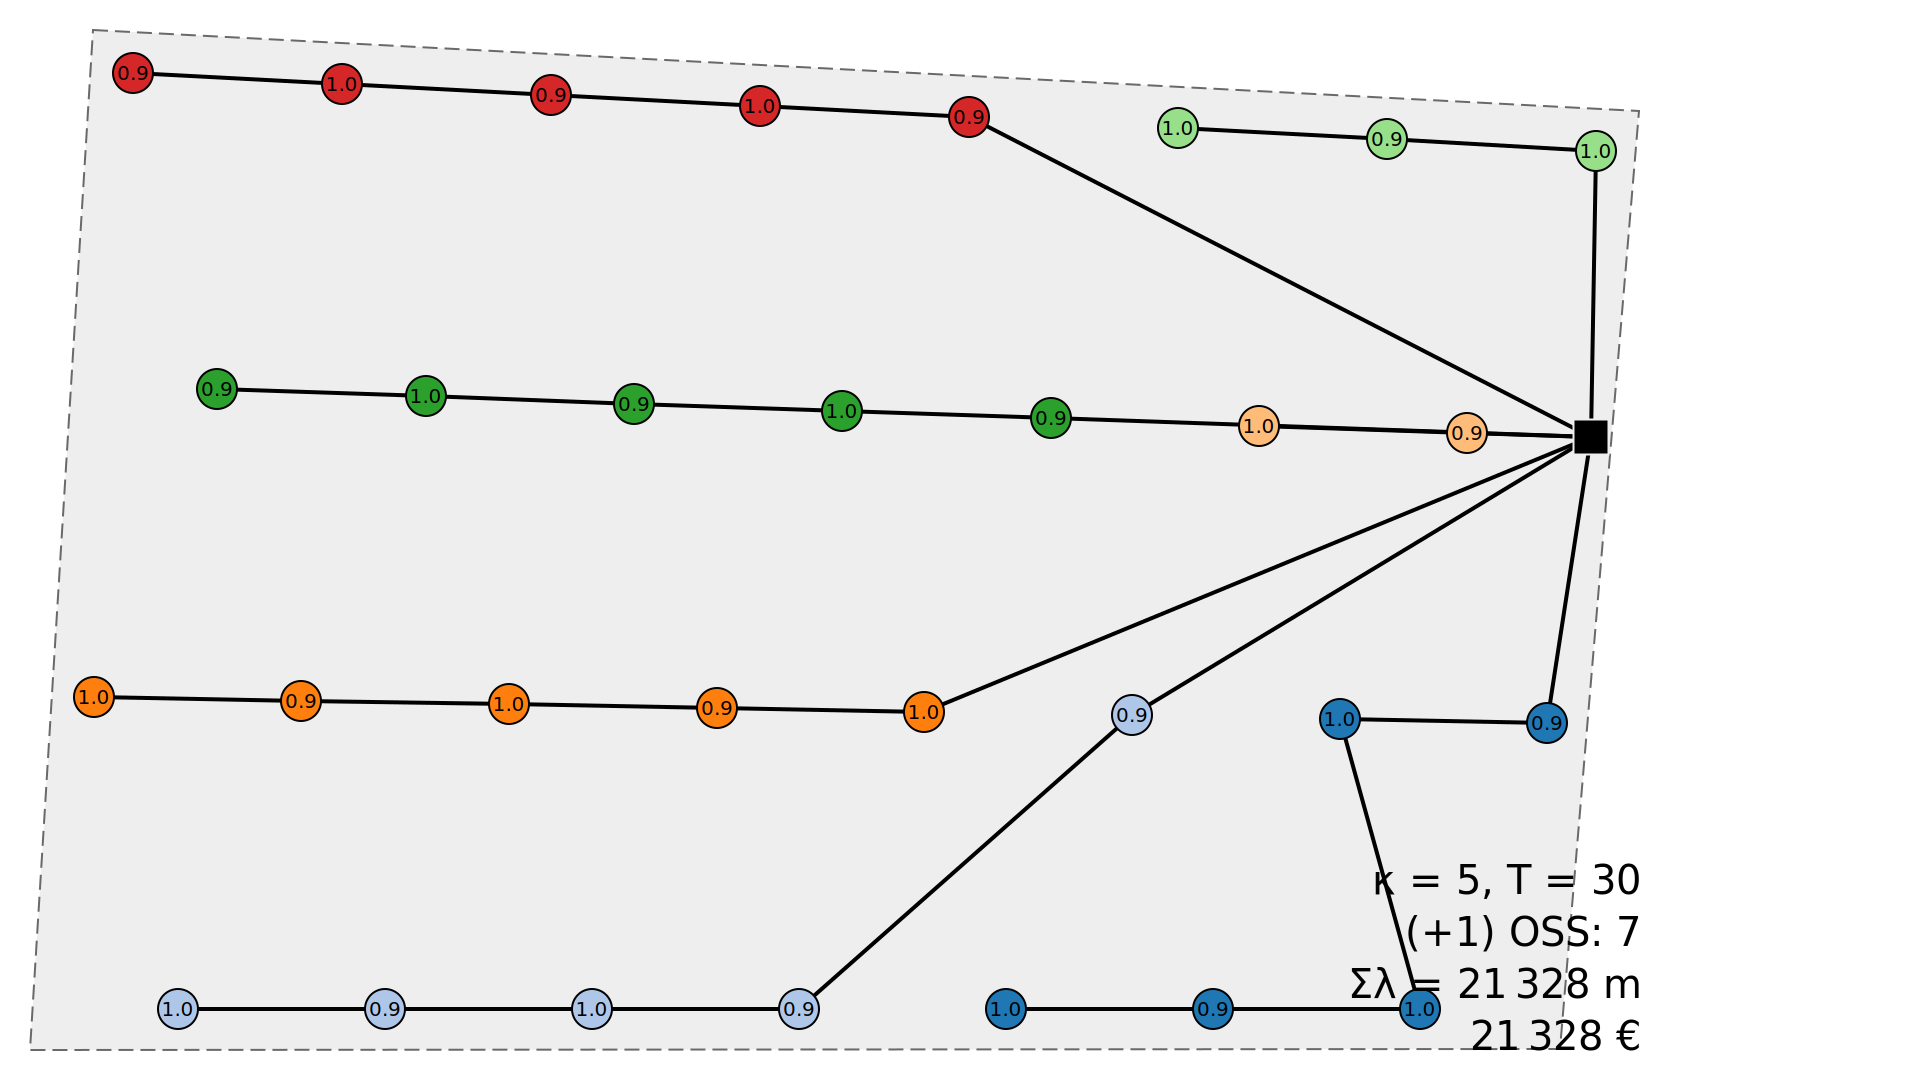

[1.0, 0.5, ...]  scale=2     0.18 s


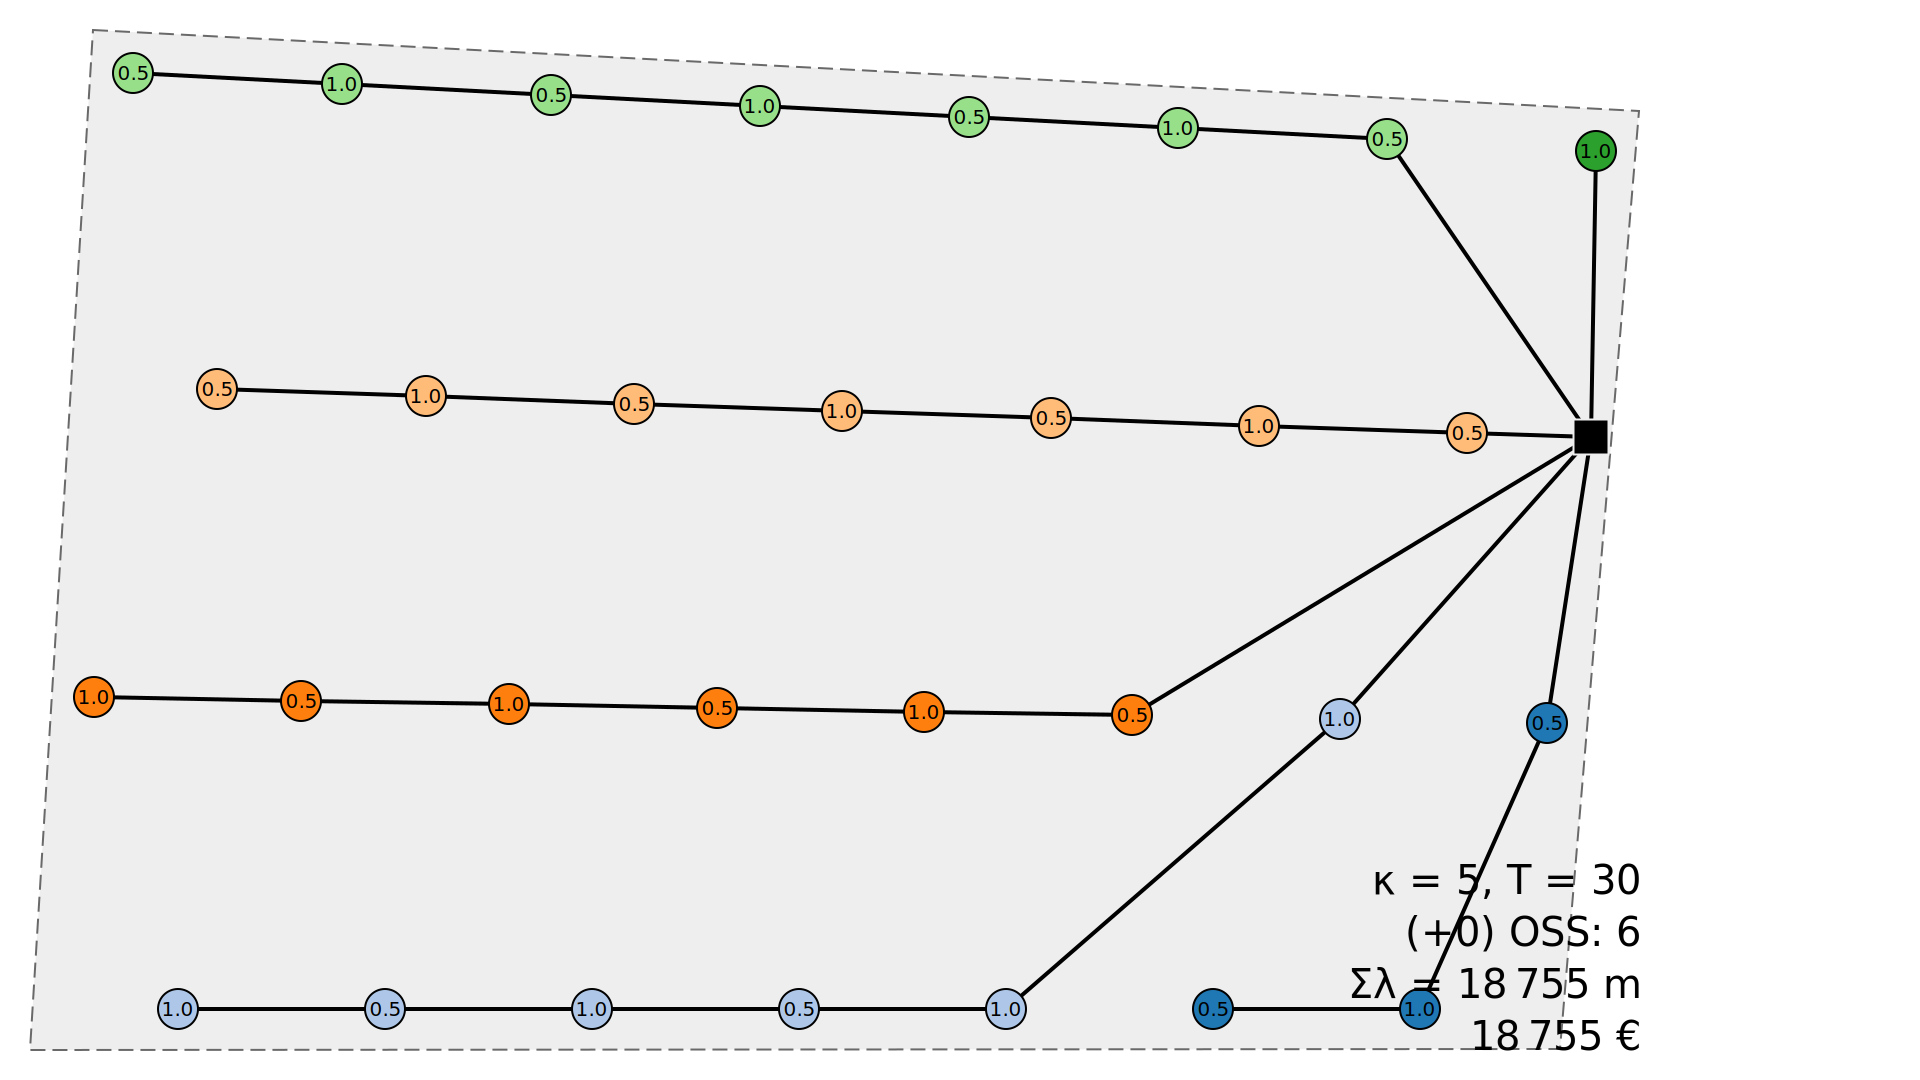

[1.0, 0.1, ...]  scale=10    0.07 s


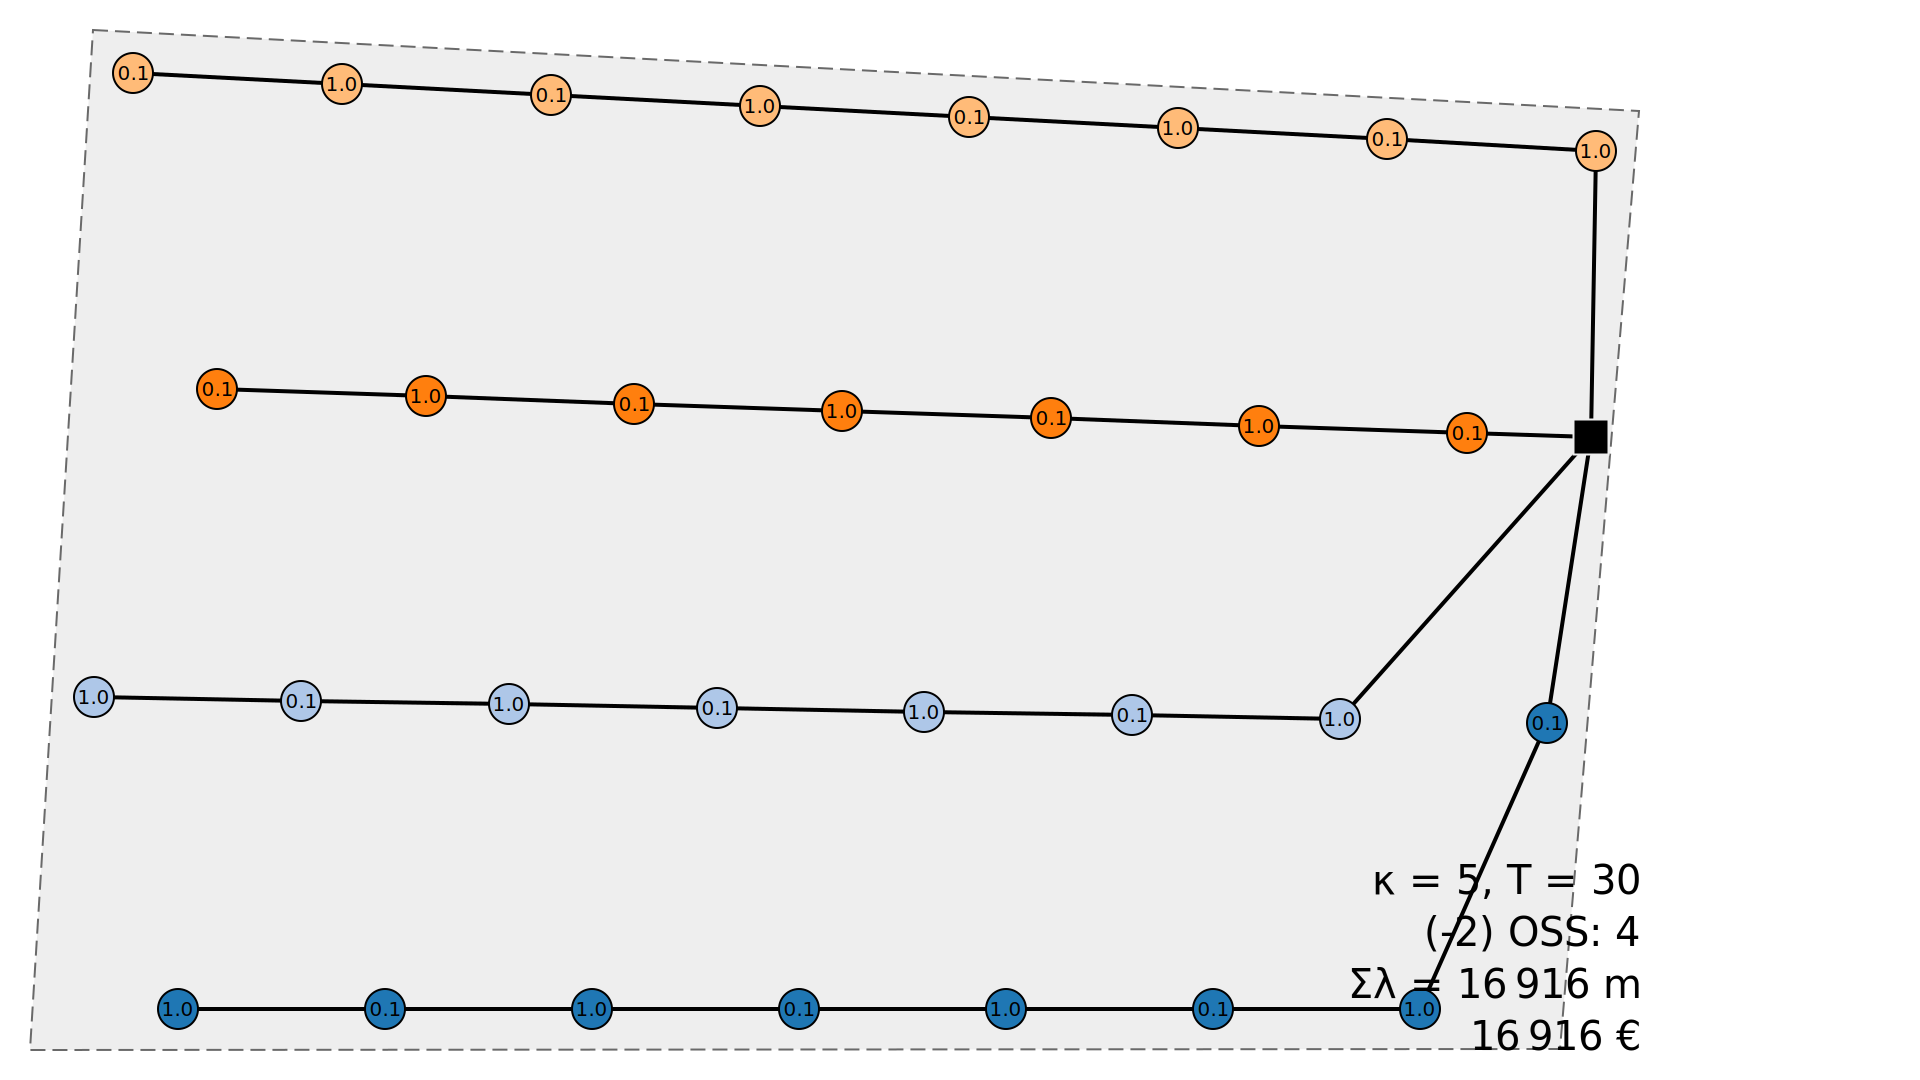

turbine_power normalization scale factor is 20. Large scale factors may slow down MILP optimization.
turbine_power normalization scale factor is 20. Large scale factors may slow down MILP optimization.


[1.0, 0.05, ...]  scale=20    0.07 s


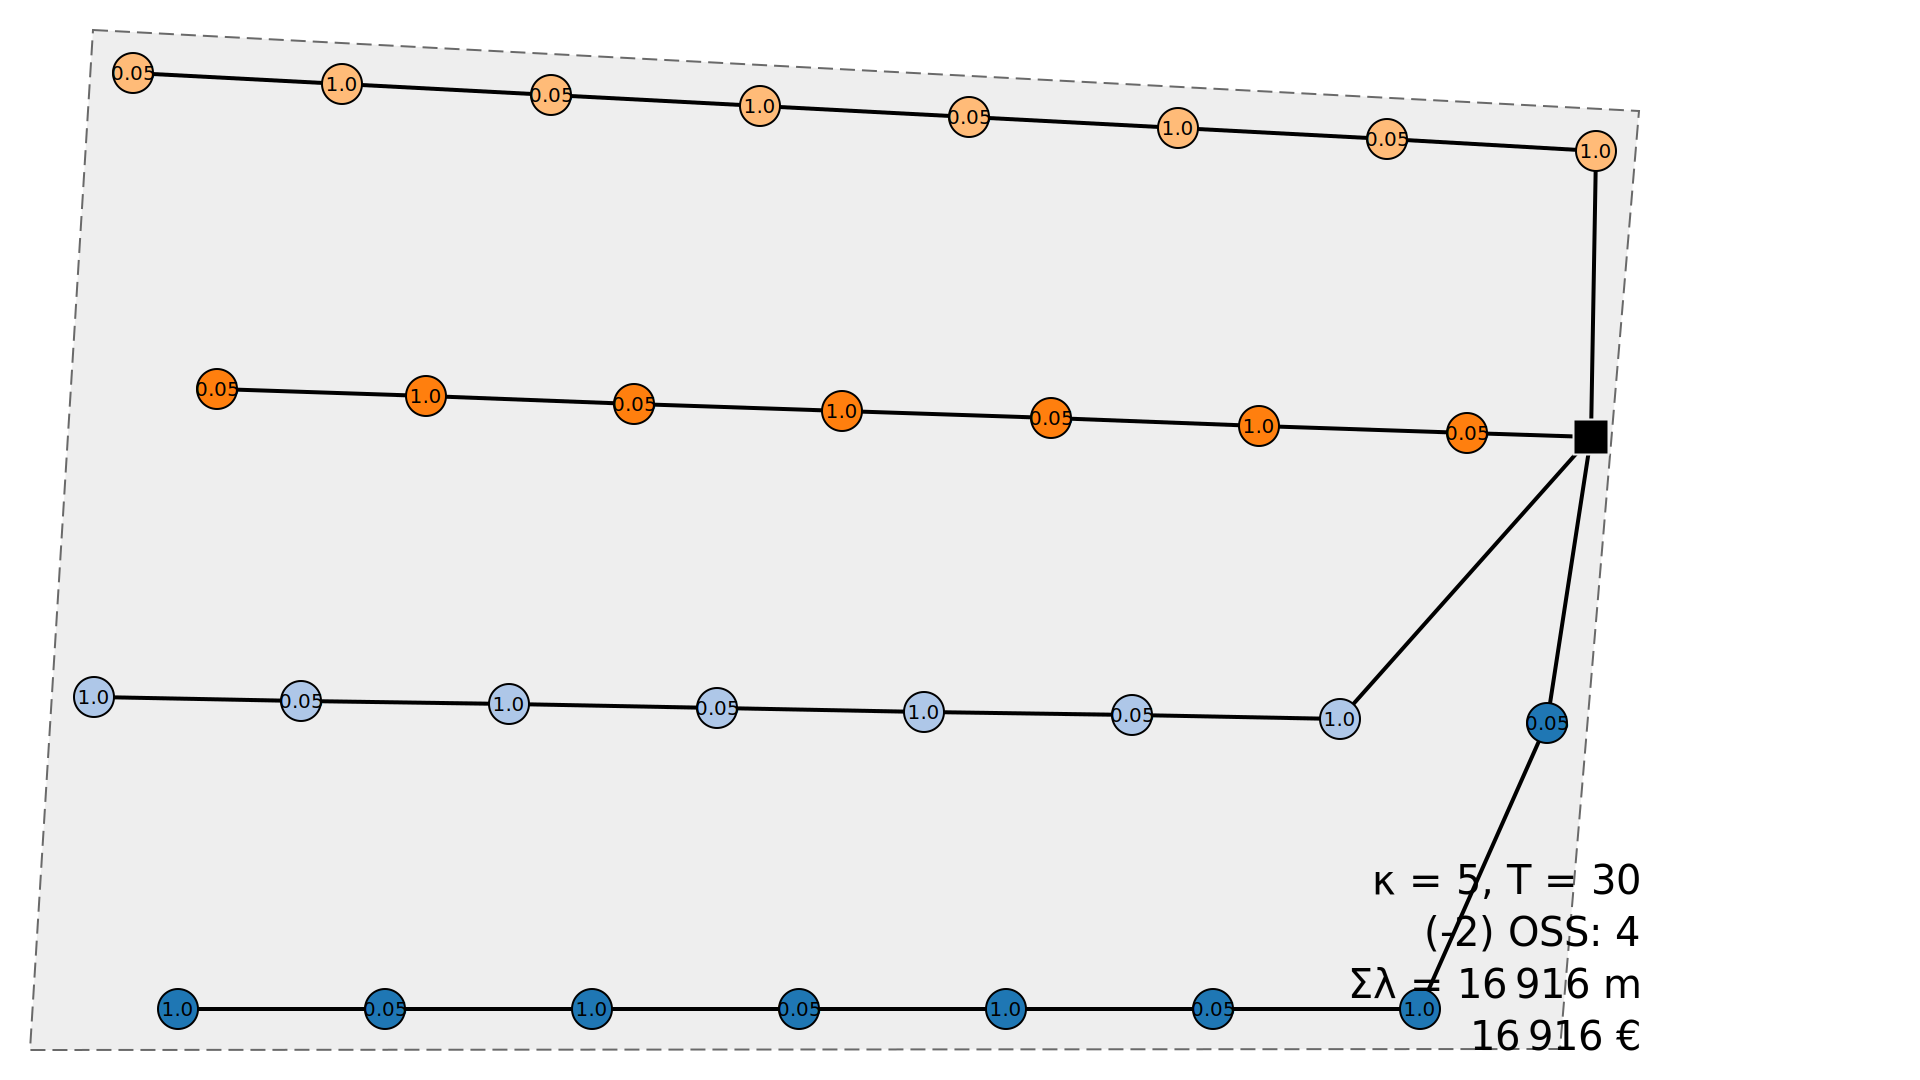

turbine_power normalization scale factor is 100. Large scale factors may slow down MILP optimization.
turbine_power normalization scale factor is 100. Large scale factors may slow down MILP optimization.


[1.0, 0.01, ...]  scale=100   0.07 s


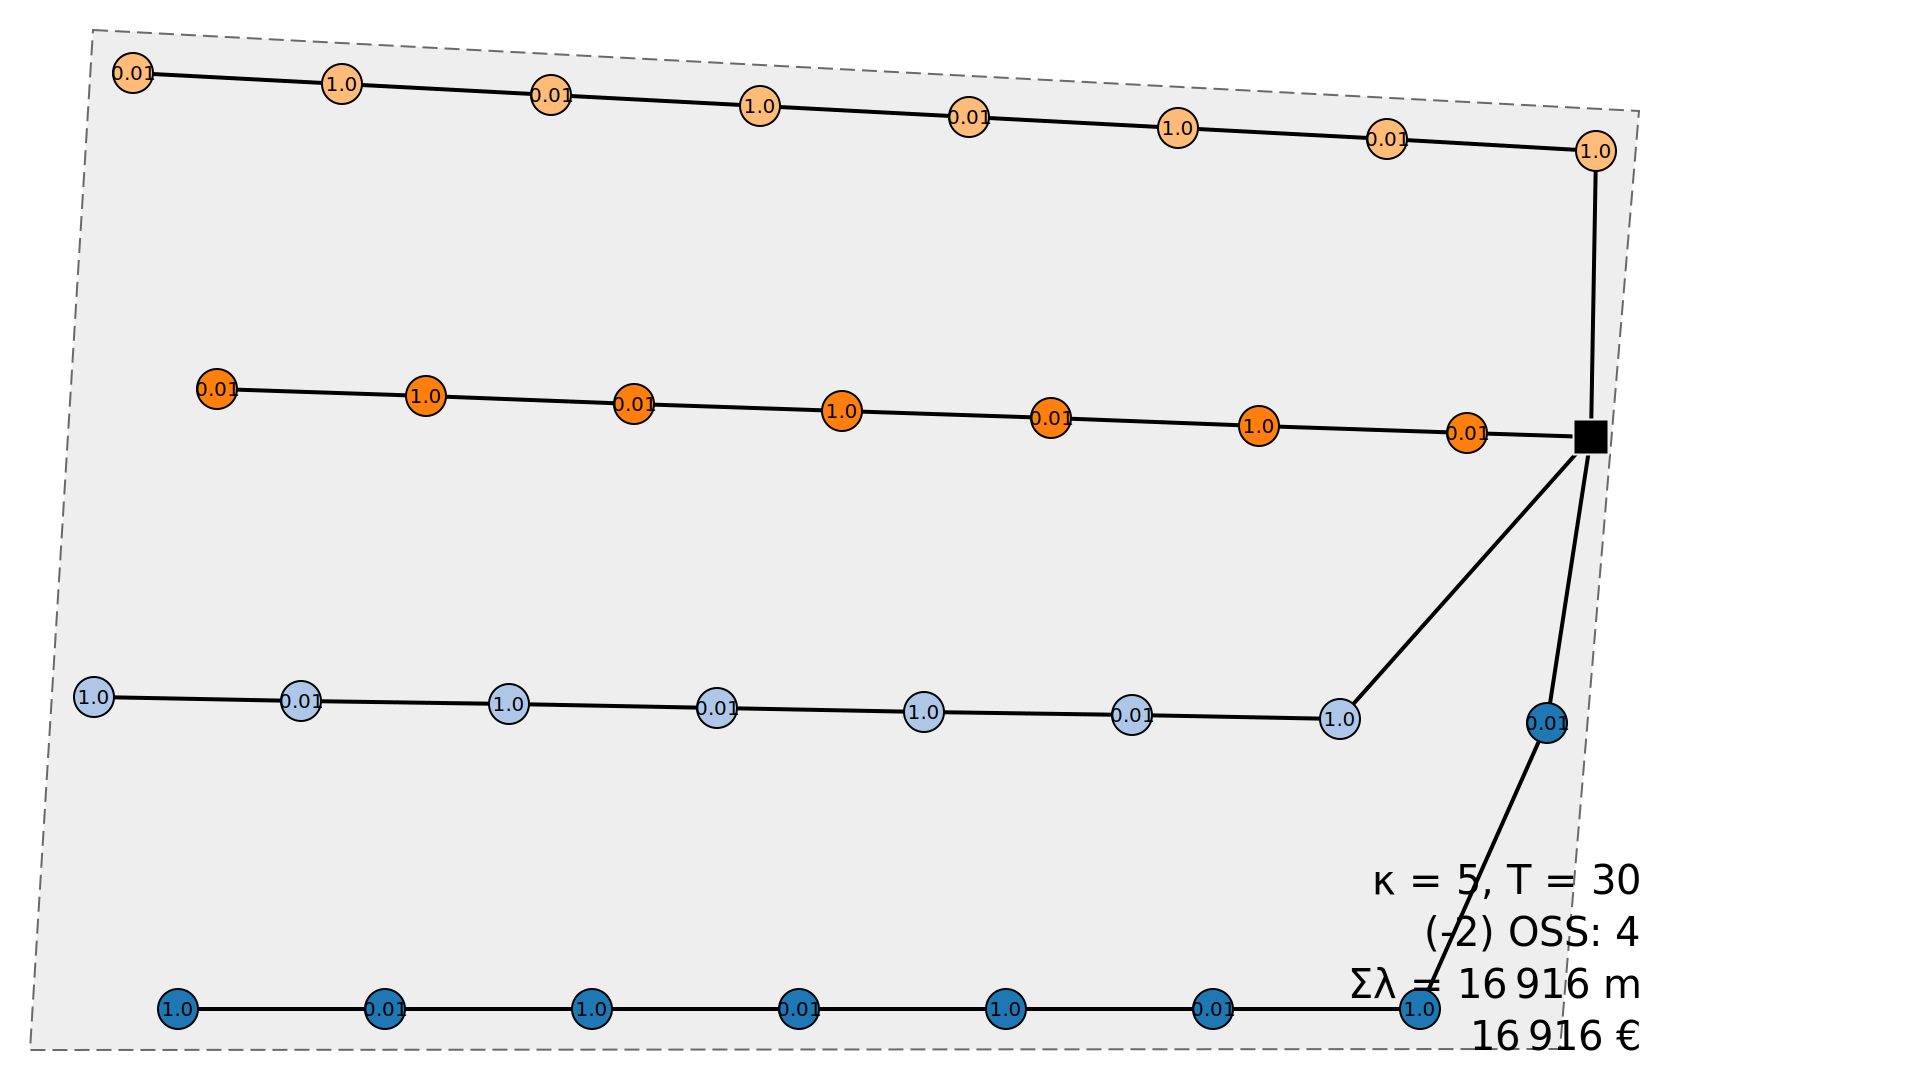

[1.0, 1.001, ...]  scale=1     3.62 s


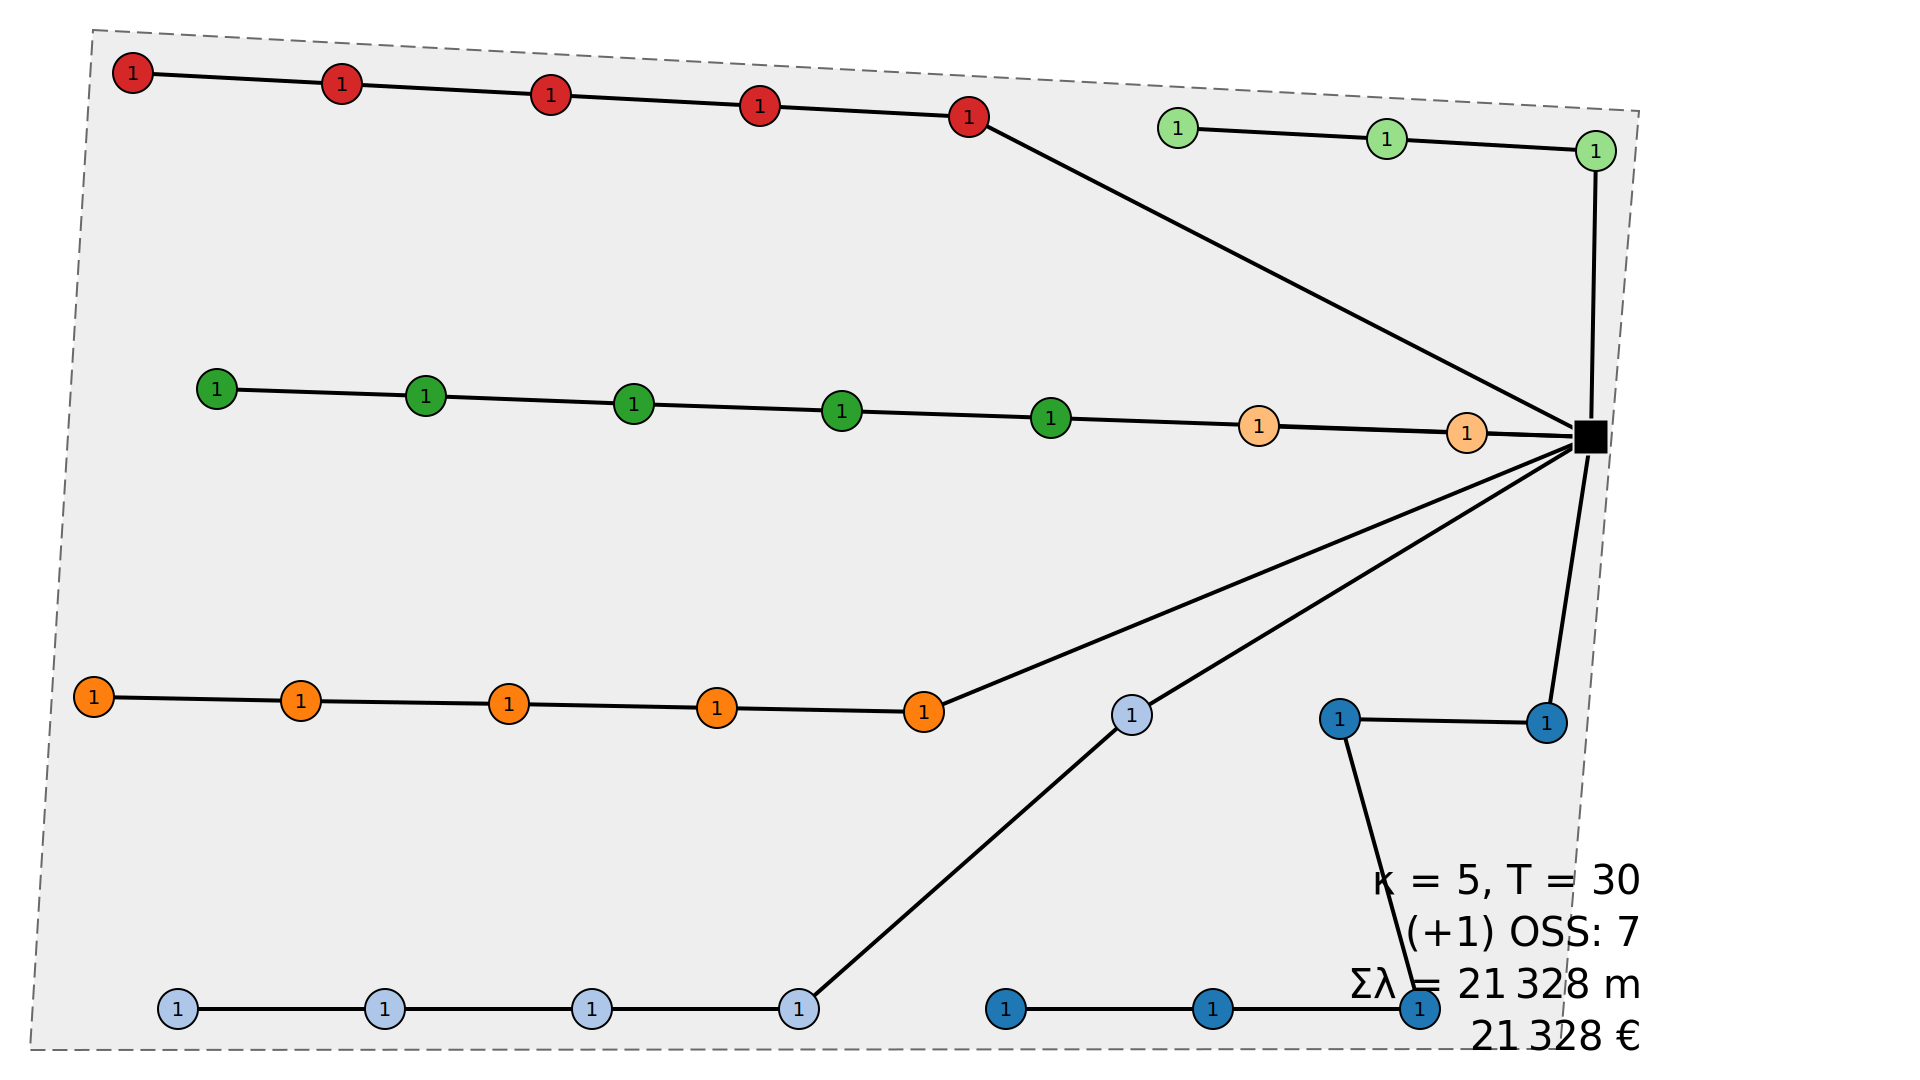

In [14]:
import time
import warnings
from importlib.resources import files
from optiwindnet.importer import L_from_yaml

from IPython.display import display

T_ormonde = 30

pairs = [
    (1.0, 1.0),
    (1.0, 2.0),
    (1.0, 3),
    (1.0, 5),
    (1.0, 1.9),
    (1.0, 1.5),
    (1.0, 1.2),
    (1.0, 1.01),
    (1.0, 0.99),
    (1.0, 0.9),
    (1.0, 0.5),
    (1.0, 0.1),
    (1.0, 0.05),
    (1.0, 0.01),
    (1.0, 1.001),
]

configs = [
    (
        f'[{a}, {b}, ...]',
        [a if i % 2 == 0 else b for i in range(T_ormonde)]
    )
    for a, b in pairs
]

for label, powers in configs:
    _, scale = _normalize_turbine_power(powers, T_ormonde)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        wfn = WindFarmNetwork(
            cables=[(5, 1.0)],
            L=L_from_yaml(files('optiwindnet.data') / 'Ormonde.yaml'),
            turbine_power=powers,
            router=MILPRouter('ortools', time_limit=60, mip_gap=0.01),
        )
    t0 = time.perf_counter()
    wfn.optimize()
    elapsed = time.perf_counter() - t0
    print(f'{label}  scale={scale:<4}  {elapsed:.2f} s')
    fig = wfn.plot(node_tag='power')
    #display(fig)



## Notes

* Power values are relative to a **nominal unit** — only their **ratios** matter. `[1.0, 2.0]` and `[3.0, 6.0]` produce the same result.
* The `cables` capacity is always expressed in **nominal power units** (i.e. the unit where `turbine_power = 1.0`). A cable with capacity 4 can carry:
  * up to 4 standard turbines (4 x 1.0 = 4 units), or
  * up to 2 high-power turbines (2 x 2.0 = 4 units), or
  * any mix whose total power sums to at most 4.

  It is **not** tied to the lowest or highest rated turbine — it is tied to whatever the user defines as `1.0`.
* Fractional values are allowed (e.g. `[1.0, 1.5]`), but simple ratios (1/2, 1/4, 3/4) keep the internal scale factor small and the solver fast.